# Payoff structures — NIFTY options

Straddle · strangle · **vertical spreads (credit and debit)** · iron fly · iron condor ·
naked call and put.

One trading day: **27 Jan 2026**, expiry **10 Feb 2026**, lot size **65**.

The forward and the discount are derived from the option prices, not read from the data — see
[`docs/calculations.md`](../docs/calculations.md).

A strategy is a **list of legs**. Every figure below comes from one payoff function and one
metrics function — no per-strategy code.

**Every structure is drawn twice — one position, two coordinate systems.** The left panel reads
the payoff against terminal spot $S_T$, the right against the forward $F$. Because
$S_T = F - b$ the second is the first translated by the basis: the caps are identical and every
breakeven differs by exactly $b$.

## 1. Setup

In [1]:
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import norm

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE = ROOT / "Data" / "sample" / "chain_2026-01-27.parquet"

# The engine's Black-76, not a second copy of it. src/payoff/pricing.py is graded against
# the Oracle in CI, so the solver below inherits that guarantee instead of re-earning it.
sys.path.insert(0, str(ROOT / "src"))
from payoff.pricing import black76_greeks, black76_price  # noqa: E402

# NIFTY lot size, confirmed 65 on 19 Aug 2026 (map #1). Margin mechanics stay open in issue #4.
LOT_SIZE = 65

TRADING_DAYS_PER_YEAR = 252  # established in issue #2

## 2. The data

NIFTY option chain, 1-minute bars, one session.

- `ts` is **UTC**. Source options are IST stamped at bar close, greeks UTC at bar open — a naive join
  returns zero rows and no warning.
- `dte_days` is a **trading-day clock**: one session consumes exactly 1.0, overnight and weekends none.
- Prices are the bar close, which is what `last` holds.

In [2]:
chain = pd.read_parquet(SAMPLE)
chain["ist"] = chain.ts + pd.Timedelta(hours=5, minutes=30)

print(f"rows      {len(chain):,}")
print(f"session   {chain.ist.min():%H:%M} -> {chain.ist.max():%H:%M} IST on {chain.ist.dt.date.iloc[0]}")
print(f"strikes   {chain.strike.nunique()}  ({chain.strike.min():.0f} - {chain.strike.max():.0f})")
print(f"dte_days  {chain.dte_days.max():.4f} at open -> {chain.dte_days.min():.4f} at close")
chain.head(3)

rows      23,581
session   09:15 -> 15:30 IST on 2026-01-27
strikes   94  (23300 - 27950)
dte_days  11.0000 at open -> 10.0000 at close


,ts,strike,option_type,Open,High,Low,Close,Volume,OpenInterest,Ticker,...,delta,gamma,theta,vega,rho,vanna,volga,charm,spot,ist
0,2026-01-27 03:45:00,23350.0,PE,19.15,19.35,19.0,19.0,1170,0,NIFTY10FEB2623350PE.NFO,...,-0.040644,0.000077,-4.294955,4.589929,-0.454762,-0.006859,0.628664,0.006734,25113.05,2026-01-27 09:15:00
1,2026-01-27 03:45:00,23400.0,PE,22.05,22.25,20.5,20.5,1755,20280,NIFTY10FEB2623400PE.NFO,...,-0.043716,0.000082,-4.531928,4.868650,-0.489155,-0.007188,0.645895,0.007020,25113.05,2026-01-27 09:15:00
2,2026-01-27 03:45:00,23450.0,PE,23.75,23.75,21.4,21.4,1820,4355,NIFTY10FEB2623450PE.NFO,...,-0.045958,0.000087,-4.658043,5.068765,-0.514183,-0.007489,0.663581,0.007221,25113.05,2026-01-27 09:15:00


### Moment

Midday IST — liquid, clear of the open and close auctions.

In [3]:
SNAPSHOT_TIME = pd.Timestamp("2026-01-27 12:00:00")

snap = chain[chain.ist == SNAPSHOT_TIME].copy()

SPOT = float(snap.spot.iloc[0])
DTE  = float(snap.dte_days.iloc[0])
T    = DTE / TRADING_DAYS_PER_YEAR

# Not inputs. Section 3 derives the forward and the discount from the option prices and
# grades the result against these two columns.
SOURCE_FORWARD  = float(snap.forward.iloc[0])
SOURCE_DISCOUNT = float(snap.discount.iloc[0])

print(f"spot      {SPOT:,.2f}")
print(f"dte_days  {DTE:.4f}   ->  T = {DTE:.4f}/252 = {T:.6f} years")
print(f"legs available: {len(snap)} across {snap.strike.nunique()} strikes")

spot      25,100.25
dte_days  10.5600   ->  T = 10.5600/252 = 0.041905 years
legs available: 58 across 49 strikes


## 3. Implied forward and discount

The forward and the discount factor are **derived from the option prices**, not read from the
data. Full derivation in [`docs/calculations.md`](../docs/calculations.md).

Put-call parity is an identity for European options on the same underlying, strike and expiry.
No model, no volatility, no distributional assumption:

$$C(K) - P(K) = D\,(F - K)$$

Read as a function of $K$ it is already a straight line:

$$\underbrace{C(K) - P(K)}_{y} \;=\; \underbrace{DF}_{a} \;+\; \underbrace{(-D)}_{m}\,K$$

So one ordinary least squares fit of $y$ on $K$ recovers both unknowns at once:

$$\hat D = -m \qquad \hat F = \frac{a}{\hat D} = -\frac{a}{m}$$

Only strikes quoting **both** a call and a put can enter — parity needs a pair.

**The gate.** OLS returns a number whether the input deserves one or not, so a fit is used only
if $n \ge 5$ and the implied rate $\hat r = -\ln \hat D / T$ falls inside $(0\%,\ 30\%)$.
Rejected minutes give $\hat D$ above 1 — a negative rate over two weeks — which would render as
a plausible-looking chart that is wrong. Those minutes are out of scope for v1 and are not
shown.

In [4]:
pairs = snap.pivot_table(index="strike", columns="option_type", values="last").dropna()
K = pairs.index.to_numpy(float)
y = (pairs.CE - pairs.PE).to_numpy(float)

m, a = np.polyfit(K, y, 1)           # y = a + m*K
DISCOUNT = -m
FORWARD = a / DISCOUNT
RATE = -np.log(DISCOUNT) / T
r2 = np.corrcoef(K, y)[0, 1] ** 2

assert len(pairs) >= 5, f"only {len(pairs)} paired strikes - fit rejected"
assert 0 < RATE < 0.30, f"implied rate {RATE:.2%} outside (0%, 30%) - fit rejected"

print(f"paired strikes   {len(pairs)}   ({K.min():,.0f} - {K.max():,.0f})")
print(f"fit              C - P = {a:,.2f} + {m:.6f} K      R2 = {r2:.6f}")
print(f"discount         {DISCOUNT:.6f}")
print(f"forward          {FORWARD:,.2f}    (basis {FORWARD - SPOT:+.2f} points over spot)")
print(f"implied rate     {RATE:.2%}   gate (0%, 30%): pass")

# Graded against the two columns solved independently upstream.
print()
print(f"{'':<12}{'ours':>14}{'source':>14}{'diff':>12}")
print(f"{'discount':<12}{DISCOUNT:>14.6f}{SOURCE_DISCOUNT:>14.6f}{DISCOUNT - SOURCE_DISCOUNT:>+12.6f}")
print(f"{'forward':<12}{FORWARD:>14,.2f}{SOURCE_FORWARD:>14,.2f}{FORWARD - SOURCE_FORWARD:>+12.2f}")
assert abs(FORWARD - SOURCE_FORWARD) < 0.01, "forward disagrees with the source"
assert abs(DISCOUNT - SOURCE_DISCOUNT) < 1e-6, "discount disagrees with the source"

paired strikes   9   (24,500 - 25,500)
fit              C - P = 25,054.69 + -0.993480 K      R2 = 0.999892
discount         0.993480
forward          25,219.12    (basis +118.87 points over spot)
implied rate     15.61%   gate (0%, 30%): pass

                      ours        source        diff
discount          0.993480      0.993480   +0.000000
forward          25,219.12     25,219.12       +0.00


### The basis

The at-the-money strike is the one nearest the **forward**, not the spot. Here the two differ by
more than two strike intervals and select different strikes — so this is not a rounding detail,
it decides which options every structure below holds.

`docs/calculations.md` §1 settles which one is correct, and **this notebook anchors on the
forward**. The gap between them is the basis

$$b \;=\; \hat F - S$$

which is also the only quantity separating the two panels in §7.

In [5]:
quoted_both = sorted(snap.groupby("strike").option_type.nunique().pipe(lambda q: q[q == 2]).index)
atm_from_spot    = min(quoted_both, key=lambda k: abs(k - SPOT))
atm_from_forward = min(quoted_both, key=lambda k: abs(k - FORWARD))

BASIS = FORWARD - SPOT

print(f"spot      {SPOT:,.2f}   -> nearest paired strike {atm_from_spot:,.0f}")
print(f"forward   {FORWARD:,.2f}   -> nearest paired strike {atm_from_forward:,.0f}")
print(f"basis     b = F_hat - S = {BASIS:+.2f} points")

# Guards the claim, not the chart layout: if these ever coincide the basis has stopped mattering.
assert atm_from_forward != atm_from_spot, "the anchors agree - the basis has stopped mattering"
print(f"the anchors disagree: {atm_from_forward:,.0f} (forward) vs {atm_from_spot:,.0f} (spot)")

spot      25,100.25   -> nearest paired strike 25,100
forward   25,219.12   -> nearest paired strike 25,200
basis     b = F_hat - S = +118.87 points
the anchors disagree: 25,200 (forward) vs 25,100 (spot)


## 4. Implied volatility

Every quantity so far came from arithmetic. This one needs a **model** and has no closed form.

Black-76 maps a volatility to a price. It is strictly increasing in $\sigma$ — more volatility is
always worth more — so the map is invertible, but only numerically:

$$\text{price} = \text{Black76}(\hat F, K, T, \sigma, D) \qquad \Longrightarrow \qquad \sigma = \;?$$

**Implied volatility** is the $\sigma$ that reproduces the quoted price. It is not a forecast. It
is the market's price restated in units that compare across strikes.

### Newton-Raphson

Define the residual and drive it to zero:

$$f(\sigma) = \text{Black76}(\hat F, K, T, \sigma, D) - \text{market}$$

Newton needs the derivative, and here the derivative is a Greek we already know — **vega**:

$$f'(\sigma) = \frac{\partial\,\text{Black76}}{\partial \sigma} = D\,\hat F\,\phi(d_1)\sqrt{T}
\qquad
d_1 = \frac{\ln(\hat F/K) + \tfrac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$$

$$\sigma_{n+1} = \sigma_n - \frac{f(\sigma_n)}{f'(\sigma_n)}$$

**A trap worth naming.** `black76_greeks` returns vega **divided by 100**, because the Oracle
quotes it per volatility *point*. Newton needs the raw $\partial P / \partial \sigma$. Using the
Oracle's vega makes every step 100 times too small — the solver still converges, just far too
slowly, so it reads as sluggishness rather than as the bug it is. The formula above is written
out in full for that reason.

### Which quote to invert

One volatility per strike, solved from the **out-of-the-money** leg only: the call when
$K \ge \hat F$, the put when $K < \hat F$.

This is not a preference. The Oracle's `iv` is *identical* for the call and the put at every
paired strike — it solves the OTM leg and copies the answer to its in-the-money twin, whose last
print is stale. Inverting the ITM quote would disagree with the Oracle by construction, and
`Data/sample/README.md` warns about exactly this.

### The seed decides whether it works at all

Newton is only locally convergent. Start far from the answer, vega is numerically zero, the step
divides by nothing, and the solve dies.

The textbook seed is Brenner-Subrahmanyam, $\sigma_0 \approx \sqrt{2\pi/T}\;\text{price}/(D\hat F)$.
It is derived for an at-the-money option and it fails badly here: for the 23,500 put it proposes
$\sigma_0 = 1.2\%$ against a true 21.4%, at which $\phi(d_1)$ underflows.

Measured on this slice, all 46 legs:

| seed | converged | median iterations |
|---|---|---|
| Brenner-Subrahmanyam | **22 / 46** | 5 |
| $\max(\text{BS},\,\sqrt{2\lvert \ln(\hat F/K)\rvert / T})$ | 46 / 46 | 6 |
| flat $\sigma_0 = 0.20$ | **46 / 46** | **4** |

A flat 20% wins on both counts. The chain quotes 15.7% to 21.4%, so a constant seed is never far
from any of them, and the cleverer seeds buy nothing.

In [6]:
VOL_LO, VOL_HI = 1e-6, 5.0     # same bracket as src/payoff/pricing.py
VOL_SEED = 0.20                # flat; see the table above
TOL, MAX_ITER = 1e-8, 50       # the tolerance is in price units, not vol units


def implied_vol_newton(price, strike, is_call):
    """Invert Black-76 for sigma. Returns (sigma, iterations)."""
    sigma = VOL_SEED
    for i in range(1, MAX_ITER + 1):
        residual = float(black76_price(FORWARD, strike, T, sigma, DISCOUNT, is_call=is_call)) - price
        if abs(residual) < TOL:
            return sigma, i
        d1 = (np.log(FORWARD / strike) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
        vega = DISCOUNT * FORWARD * norm.pdf(d1) * np.sqrt(T)      # RAW, not the Oracle's /100
        if vega < 1e-12:
            raise ArithmeticError(f"vega collapsed at {strike:,.0f}, sigma={sigma:.4f}")
        nxt = float(np.clip(sigma - residual / vega, VOL_LO, VOL_HI))
        if nxt == sigma:
            return sigma, i
        sigma = nxt
    raise ArithmeticError(f"no convergence at {strike:,.0f} after {MAX_ITER} iterations")


otm = snap[((snap.option_type == "CE") & (snap.strike >= FORWARD))
           | ((snap.option_type == "PE") & (snap.strike < FORWARD))].sort_values("strike")

SLICE = pd.DataFrame({
    "strike": otm.strike.to_numpy(float),
    "type": otm.option_type.to_numpy(),
    "moneyness": otm.strike.to_numpy(float) / FORWARD,
    "market": otm.last.to_numpy(float),
    "oracle_iv": otm.iv.to_numpy(float),
})
solved = [implied_vol_newton(p, k, t == "CE")
          for p, k, t in zip(SLICE.market, SLICE.strike, SLICE.type)]
SLICE["iv"] = [v for v, _ in solved]
SLICE["iters"] = [n for _, n in solved]
SLICE["repriced"] = [float(black76_price(FORWARD, k, T, v, DISCOUNT, is_call=(t == "CE")))
                     for k, v, t in zip(SLICE.strike, SLICE.iv, SLICE.type)]

print(f"legs inverted   {len(SLICE)}   ({(SLICE.type == 'PE').sum()} puts, {(SLICE.type == 'CE').sum()} calls)")
print(f"moneyness K/F   {SLICE.moneyness.min():.4f} - {SLICE.moneyness.max():.4f}")
print(f"implied vol     {SLICE.iv.min():.2%} - {SLICE.iv.max():.2%}")
print(f"iterations      min {SLICE.iters.min()}, median {SLICE.iters.median():.0f}, max {SLICE.iters.max()}")
print()
print(f"vs the Oracle iv   max abs difference {abs(SLICE.iv - SLICE.oracle_iv).max():.2e}")
print(f"round-trip price   max abs difference {abs(SLICE.repriced - SLICE.market).max():.2e}")

assert abs(SLICE.iv - SLICE.oracle_iv).max() < 1e-9, "solver disagrees with the Oracle"
assert abs(SLICE.repriced - SLICE.market).max() < 1e-6, "solved vol does not reprice the quote"
assert SLICE.iters.max() <= 10, "convergence slower than expected - check the vega scale"

legs inverted   46   (22 puts, 24 calls)
moneyness K/F   0.9318 - 1.1083
implied vol     15.74% - 21.36%
iterations      min 3, median 4, max 5

vs the Oracle iv   max abs difference 7.93e-12
round-trip price   max abs difference 3.70e-09


### The slice

One expiry and one minute, so this is a two-dimensional cut through what would otherwise be a
surface: volatility against moneyness, with time held fixed.

It is not flat, and that is the whole point. If Black-76 were literally true the line would be
horizontal — one underlying, one volatility. Every departure from horizontal is the market
disagreeing with the model.

Two separate features are visible, and they are usually confused with each other:

**The smile.** Both wings sit above the middle. The minimum is 15.74% at $K/\hat F = 1.033$,
while the far put reaches 21.36% and the far call 21.11%. Away from the money in *either*
direction the market charges more than one flat volatility would, because real returns have
fatter tails than the lognormal Black-76 assumes.

**The skew.** The two wings are not level with each other. Compare strikes equidistant from the
forward:

| distance from $\hat F$ | put | call | put $-$ call |
|---|---|---|---|
| 3% | 18.20% | 15.82% | +2.38 |
| 5% | 19.61% | 16.60% | +3.01 |
| 7% | 21.36% | 17.87% | +3.49 |

The put side is dearer at every distance, and the gap widens further out. That is the index
skew: downside protection costs more than the equivalent upside, because crashes are faster
than rallies and everybody holding the index wants the same hedge at the same moment.

The minimum sitting *above* the forward rather than on it is the same effect seen from the
other side — the cheapest volatility in this chain is a slightly out-of-the-money call.

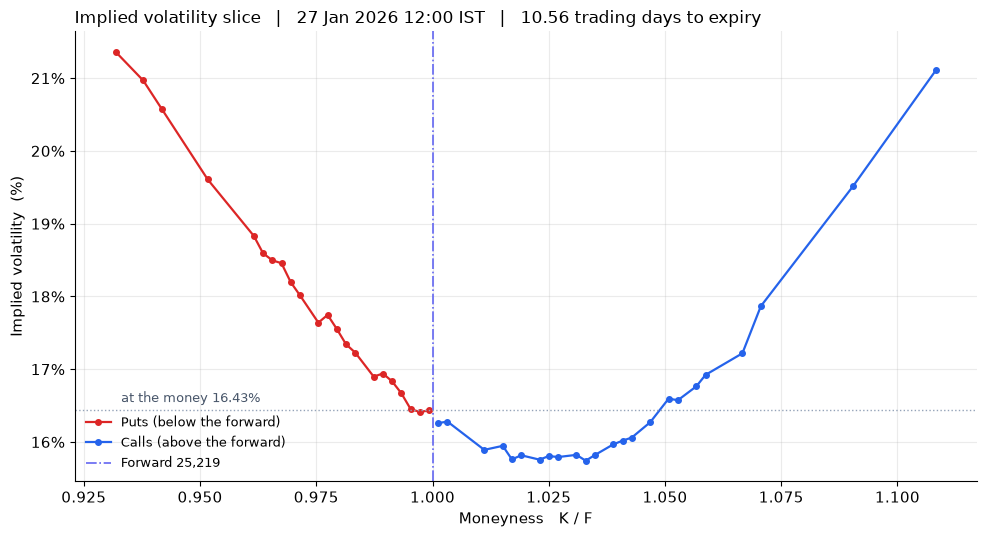

     strike type  moneyness   market      iv  iters
23,500.0000   PE     0.9318  23.7500 21.3600      5
23,650.0000   PE     0.9378  30.7500 20.9700      5
23,750.0000   PE     0.9417  35.5500 20.5800      4
24,000.0000   PE     0.9517  51.2500 19.6100      4
24,250.0000   PE     0.9616  76.4500 18.8300      4
24,300.0000   PE     0.9636  81.7000 18.5900      4
24,350.0000   PE     0.9655  89.2000 18.5000      4
24,400.0000   PE     0.9675  98.0500 18.4600      4
24,450.0000   PE     0.9695 104.4500 18.2000      4
24,500.0000   PE     0.9715 112.5000 18.0200      4
24,600.0000   PE     0.9755 130.2000 17.6400      4
24,650.0000   PE     0.9774 144.9000 17.7500      4
24,700.0000   PE     0.9794 155.5000 17.5500      4
24,750.0000   PE     0.9814 166.5500 17.3400      4
24,800.0000   PE     0.9834 180.1000 17.2300      4
24,900.0000   PE     0.9873 208.0500 16.9000      4
24,950.0000   PE     0.9893 227.4500 16.9400      4
25,000.0000   PE     0.9913 245.0000 16.8300      4
25,050.0000 

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for kind, colour, label in [("PE", "#dc2626", "Puts (below the forward)"),
                            ("CE", "#2563eb", "Calls (above the forward)")]:
    part = SLICE[SLICE.type == kind]
    ax.plot(part.moneyness, part.iv * 100, "o-", color=colour, lw=1.6, ms=4, label=label)

ax.axvline(1.0, color="#6366f1", ls="-.", lw=1.2, label=f"Forward {FORWARD:,.0f}")
atm_iv = float(SLICE.iv.iloc[(SLICE.moneyness - 1.0).abs().argmin()])
ax.axhline(atm_iv * 100, color="#94a3b8", ls=":", lw=1.0)
ax.annotate(f"at the money {atm_iv:.2%}", (SLICE.moneyness.min(), atm_iv * 100),
            textcoords="offset points", xytext=(4, 6), fontsize=9, color="#475569")

ax.set_title(f"Implied volatility slice   |   {SNAPSHOT_TIME:%d %b %Y %H:%M} IST   "
             f"|   {DTE:.2f} trading days to expiry", fontsize=12, loc="left")
ax.set_xlabel("Moneyness   K / F")
ax.set_ylabel("Implied volatility  (%)")
ax.legend(frameon=False, fontsize=9)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0f}%")
plt.tight_layout()
plt.show()

print(SLICE[["strike", "type", "moneyness", "market", "iv", "iters"]]
      .assign(iv=lambda d: (d.iv * 100).round(2))
      .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

## 5. Legs and strategies

A **leg** is one contract: strike, type, direction, quantity, entry price.
A **strategy** is a list of legs — an iron condor is four legs, not a type.

In [8]:
@dataclass(frozen=True)
class Leg:
    strike: float
    option_type: str      # "CE" or "PE"
    direction: int        # +1 bought, -1 sold
    entry_price: float
    iv: float
    quantity: int = 1

    @property
    def is_call(self):
        return self.option_type == "CE"

    def __repr__(self):
        side = "B" if self.direction > 0 else "S"
        return f"{side} {self.quantity}x {self.strike:.0f} {self.option_type} @ {self.entry_price:.2f}"


def leg_from_chain(strike, option_type, direction, quantity=1, snapshot=None):
    '''Build a Leg from the observed chain. Entry price is the 1-min bar close.'''
    snapshot = snap if snapshot is None else snapshot
    row = snapshot[(snapshot.strike == strike) & (snapshot.option_type == option_type)]
    if row.empty:
        raise KeyError(f"{strike:.0f} {option_type} not quoted at this minute")
    row = row.iloc[0]
    return Leg(strike, option_type, direction, float(row.last), float(row.iv), quantity)

### Strikes

Outer legs sit at the **nearest quoted strike at least $w$ points away**, not at
$\text{ATM} \pm w$ — the chain has gaps and an unquoted strike cannot be traded. The width is
then read back off the strikes actually used, never assumed from the nominal offset.

In [9]:
quoted = snap.groupby("strike").option_type.nunique()
both_sides = set(quoted[quoted == 2].index)          # strikes with a live CE and PE

# A fly or condor wing is a single option, so it does not need the strike quoted on both sides -
# and at this minute nothing above 25,500 is. Restricting the wings to `both_sides` would leave
# the far call wing unbuildable.
ce_strikes = set(snap.loc[snap.option_type == "CE", "strike"])
pe_strikes = set(snap.loc[snap.option_type == "PE", "strike"])

WING   = 300     # strangle
NEAR   = 300     # fly wings
FAR    = 600     # condor wings
SPREAD = 300     # vertical spreads


def build_strategies(atm):
    """Every structure in this notebook, built around one at-the-money strike."""
    otm_call = min(k for k in both_sides if k >= atm + WING)
    otm_put  = max(k for k in both_sides if k <= atm - WING)
    fly_call = min(k for k in ce_strikes if k >= atm + NEAR)
    fly_put  = max(k for k in pe_strikes if k <= atm - NEAR)
    con_call = min(k for k in ce_strikes if k >= atm + FAR)
    con_put  = max(k for k in pe_strikes if k <= atm - FAR)
    up_call  = min(k for k in ce_strikes if k >= atm + SPREAD)
    dn_put   = max(k for k in pe_strikes if k <= atm - SPREAD)

    strategies = {
        "Long Straddle":    [leg_from_chain(atm, "CE", +1), leg_from_chain(atm, "PE", +1)],
        "Short Straddle":   [leg_from_chain(atm, "CE", -1), leg_from_chain(atm, "PE", -1)],
        "Long Strangle":    [leg_from_chain(otm_call, "CE", +1), leg_from_chain(otm_put, "PE", +1)],
        # Vertical spreads. Same two strikes each time; the signs decide debit or credit.
        "Bull Call Spread": [leg_from_chain(atm, "CE", +1), leg_from_chain(up_call, "CE", -1)],
        "Bear Call Spread": [leg_from_chain(atm, "CE", -1), leg_from_chain(up_call, "CE", +1)],
        "Bull Put Spread":  [leg_from_chain(atm, "PE", -1), leg_from_chain(dn_put, "PE", +1)],
        "Bear Put Spread":  [leg_from_chain(atm, "PE", +1), leg_from_chain(dn_put, "PE", -1)],
        "Iron Fly":         [leg_from_chain(atm, "CE", -1), leg_from_chain(atm, "PE", -1),
                             leg_from_chain(fly_call, "CE", +1), leg_from_chain(fly_put, "PE", +1)],
        "Iron Condor":      [leg_from_chain(fly_call, "CE", -1), leg_from_chain(fly_put, "PE", -1),
                             leg_from_chain(con_call, "CE", +1), leg_from_chain(con_put, "PE", +1)],
        "Naked Long Call":  [leg_from_chain(atm, "CE", +1)],
        "Naked Short Call": [leg_from_chain(atm, "CE", -1)],
        "Naked Long Put":   [leg_from_chain(atm, "PE", +1)],
        "Naked Short Put":  [leg_from_chain(atm, "PE", -1)],
    }
    strikes = {"atm": atm, "otm_call": otm_call, "otm_put": otm_put,
               "fly_call": fly_call, "fly_put": fly_put,
               "con_call": con_call, "con_put": con_put,
               "up_call": up_call, "dn_put": dn_put}
    return strategies, strikes


# One position per structure, anchored on the forward.
ATM = min(both_sides, key=lambda k: abs(k - FORWARD))
STRATEGIES, STRIKES = build_strategies(ATM)


@dataclass(frozen=True)
class Framing:
    """A coordinate system for the payoff x-axis. Data, not a code path."""

    name: str        # "spot" | "forward"
    symbol: str      # the axis variable
    level: float     # reference line, and the centre of the plotted window
    shift: float     # added to every x-coordinate: 0 for spot, b for forward


SPOT_FRAMING    = Framing("spot",    "S_T", SPOT,    0.0)
FORWARD_FRAMING = Framing("forward", "F",   FORWARD, BASIS)
FRAMINGS = (SPOT_FRAMING, FORWARD_FRAMING)


def pair(lo, hi):
    return f"{lo:,.0f} / {hi:,.0f}"


print(f"ATM (nearest the forward)  {ATM:,.0f}")
print(f"  strangle wings           {pair(STRIKES['otm_put'], STRIKES['otm_call'])}")
print(f"  vertical spread strikes  {pair(STRIKES['dn_put'], STRIKES['up_call'])}")
print(f"  fly wings                {pair(STRIKES['fly_put'], STRIKES['fly_call'])}")
print(f"  condor wings             {pair(STRIKES['con_put'], STRIKES['con_call'])}")

print(f"\n{'framing':<10}{'symbol':>8}{'level':>13}{'shift':>10}")
for f in FRAMINGS:
    print(f"{f.name:<10}{f.symbol:>8}{f.level:>13,.2f}{f.shift:>10,.2f}")

print(f"\n{len(STRATEGIES)} structures, one position each:")
for name, legs in STRATEGIES.items():
    print(f"  {name:<18} {legs}")

ATM (nearest the forward)  25,200
  strangle wings           24,800 / 25,500
  vertical spread strikes  24,900 / 25,500
  fly wings                24,900 / 25,500
  condor wings             24,600 / 25,800

framing     symbol        level     shift
spot           S_T    25,100.25      0.00
forward          F    25,219.12    118.87

13 structures, one position each:
  Long Straddle      [B 1x 25200 CE @ 344.05, B 1x 25200 PE @ 326.70]
  Short Straddle     [S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70]
  Long Strangle      [B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10]
  Bull Call Spread   [B 1x 25200 CE @ 344.05, S 1x 25500 CE @ 206.20]
  Bear Call Spread   [S 1x 25200 CE @ 344.05, B 1x 25500 CE @ 206.20]
  Bull Put Spread    [S 1x 25200 PE @ 326.70, B 1x 24900 PE @ 208.05]
  Bear Put Spread    [B 1x 25200 PE @ 326.70, S 1x 24900 PE @ 208.05]
  Iron Fly           [S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70, B 1x 25500 CE @ 206.20, B 1x 24900 PE @ 208.05]
  Iron Condor        [S 

## 6. Payoff at expiry

A leg settles against **spot**, so intrinsic value is unavoidably a function of the terminal
index. All time value has decayed:

$$C_T = \max(S_T - K,\;0) \qquad P_T = \max(K - S_T,\;0)$$

Per leg, with direction $d = \pm 1$, quantity $q$, entry price $e$:

$$\Pi_{\text{leg}}(S_T) = d\,q\,\bigl(V(S_T) - e\bigr)$$

Strategy over $n$ legs at lot size $L$:

$$\Pi(S_T) \;=\; L \sum_{i=1}^{n} d_i\,q_i \bigl(V_i(S_T) - e_i\bigr)$$

One sum, any number of legs.

### The same payoff in forward coordinates

Substituting $S_T = F - b$:

$$\max(S_T - K,\;0) = \max\bigl(F - (K + b),\;0\bigr)
\qquad
\max(K - S_T,\;0) = \max\bigl((K + b) - F,\;0\bigr)$$

So in forward coordinates **the effective strike is $K + b$**, and

$$\boxed{\;\Pi_F(F) \;=\; \Pi(F - b)\;}$$

The forward payoff is the spot payoff **translated right by $b$**. Nothing else happens to it.

Notation, since all three appear: $\hat F$ is the forward **now**, fitted in §3;
$F$ is the forward as a **payoff coordinate**; $b = \hat F - S$ is the basis.

This substitution is exact **at expiry only** — it uses today's basis for a payoff realised when
the basis is zero. It is a way of reading the expiry line, the only line drawn here, and must not
be carried onto a target-date curve.

In [10]:
def intrinsic_value(spot, strike, is_call):
    spot = np.asarray(spot, float)
    return np.maximum(spot - strike, 0.0) if is_call else np.maximum(strike - spot, 0.0)


def payoff_at_expiry(spot, legs, lot_size=1):
    """Strategy P&L at expiry, for a scalar or array of terminal spots."""
    total = np.zeros_like(np.asarray(spot, float))
    for leg in legs:
        value = intrinsic_value(spot, leg.strike, leg.is_call)
        total = total + leg.direction * leg.quantity * (value - leg.entry_price)
    return total * lot_size


def payoff_in(x, legs, framing, lot_size=1):
    """Payoff at x, where x is read in `framing`'s coordinate. x - shift is the terminal spot."""
    return payoff_at_expiry(np.asarray(x, float) - framing.shift, legs, lot_size)


# A long straddle must lose exactly the premium paid if the index settles on its strike - and the
# strike sits at ATM in spot coordinates, ATM + b in forward ones.
legs = STRATEGIES["Long Straddle"]
premium = sum(leg.direction * leg.quantity * leg.entry_price for leg in legs)
for framing in FRAMINGS:
    at_strike = payoff_in(ATM + framing.shift, legs, framing)
    assert np.isclose(at_strike, -premium)
    print(f"{framing.name:<9} strike sits at {ATM + framing.shift:>10,.2f}   "
          f"P&L {float(at_strike):>9,.2f}   = -premium {-premium:,.2f}   ok")

spot      strike sits at  25,200.00   P&L   -670.75   = -premium -670.75   ok
forward   strike sits at  25,318.87   P&L   -670.75   = -premium -670.75   ok


## 7. Max profit, max loss, breakevens

$\Pi$ is piecewise linear in $S_T$ and bends only at a strike, so the extremes are exact rather
than searched for. Candidate points:

$$\mathcal{K} = \{0\} \cup \{K_1, \dots, K_m\}$$

Tail slopes:

$$s_{\text{right}} = \sum_{\text{calls}} d_i q_i
\qquad
s_{\text{left}} = -\sum_{\text{puts}} d_i q_i$$

$$\text{max profit} =
\begin{cases}
\infty & s_{\text{right}} > 0\\[2pt]
\max_{S_T \in \mathcal{K}} \Pi(S_T) & \text{otherwise}
\end{cases}
\qquad
\text{max loss} =
\begin{cases}
-\infty & s_{\text{right}} < 0\\[2pt]
\min_{S_T \in \mathcal{K}} \Pi(S_T) & \text{otherwise}
\end{cases}$$

**Only the right tail is unbounded.** $S_T \ge 0$, so the left tail terminates — which is why $0$
is a candidate point. A long put feels unlimited as the index collapses and is not: its profit
stops at $K - e$.

Breakevens: $\Pi$ is affine between adjacent candidates, so every sign change yields one root

$$S_T^{*} = S_j - \Pi(S_j)\,\frac{S_{j+1} - S_j}{\Pi(S_{j+1}) - \Pi(S_j)}$$

Both tails flat, $s_{\text{left}} = s_{\text{right}} = 0$, means both caps are finite — that is
what **defined risk** is, and it covers every vertical spread and both iron structures below.

### What changes in forward coordinates

$\Pi_F(F) = \Pi(F - b)$ is a **translation**, so:

1. **max profit, max loss and net premium are identical.** A horizontal shift moves no $y$-value,
   and premiums are prices paid — they have no axis at all.
2. **Every breakeven shifts by exactly $+b$.**
3. **The left tail terminates at $F = b$, not $F = 0$.**

That third one is a trap. The candidate set in forward coordinates is

$$\mathcal{K}_F = \{b\} \cup \{K_i + b\}$$

Reusing $0$ evaluates the payoff at $S_T = -b$, a negative index. On the naked long put it returns
**1,624,490.77** against a true **1,616,764.50** — no error, no `NaN`, 0.48% high, and it would
survive review.

The defence is not to re-derive anything in forward space: **compute once in spot coordinates,
where the floor is unambiguously zero, then translate the $x$-quantities.** There is then no
second candidate set to get wrong.

In [11]:
def strategy_metrics(legs, lot_size=1):
    strikes = sorted({leg.strike for leg in legs})

    right_slope = sum(leg.direction * leg.quantity for leg in legs if leg.is_call)
    left_slope  = -sum(leg.direction * leg.quantity for leg in legs if not leg.is_call)

    # candidates: every kink, plus S_T = 0 where the left tail terminates
    candidates = payoff_at_expiry(np.array([0.0] + strikes, float), legs, lot_size)

    # only the upside is genuinely unbounded - the index cannot fall below zero
    max_profit = np.inf if right_slope > 0 else float(candidates.max())
    max_loss = -np.inf if right_slope < 0 else float(candidates.min())

    # breakevens: fine scan for sign changes, then solve exactly inside each bracket
    pad = max(strikes[-1] - strikes[0], 1000) + 2000
    grid = np.linspace(0.0, strikes[-1] + pad, 20_000)
    pnl = payoff_at_expiry(grid, legs, lot_size)
    breakevens = []
    for i in np.where(np.sign(pnl[:-1]) * np.sign(pnl[1:]) < 0)[0]:
        root = brentq(lambda s: payoff_at_expiry(s, legs, lot_size), grid[i], grid[i + 1])
        breakevens.append(round(float(root), 2))

    net = sum(leg.direction * leg.quantity * leg.entry_price for leg in legs) * lot_size
    return {
        "max_profit": max_profit,
        "max_loss": max_loss,
        "breakevens": breakevens,
        "net_premium": net,          # positive = paid (debit), negative = received (credit)
        "left_slope": left_slope,
        "right_slope": right_slope,
    }


def metrics_in(legs, framing, lot_size=1):
    """Spot-space metrics with the x-quantities translated into `framing`'s coordinate."""
    m = dict(strategy_metrics(legs, lot_size))
    m["breakevens"] = [round(v + framing.shift, 2) for v in m["breakevens"]]
    m["strikes"] = [k + framing.shift for k in sorted({leg.strike for leg in legs})]
    m["floor"] = framing.shift          # where the left tail terminates in this coordinate
    return m


def fmt(x):
    if x == np.inf or x == -np.inf:
        return "Unlimited"
    return f"{x:,.0f}"


def fmt_bes(values):
    return ", ".join(f"{v:,.2f}" for v in values) or "-"


hdr = f"{'structure':<18}{'max profit':>12}{'max loss':>12}{'breakevens (S_T)':>26}{'breakevens (F)':>26}"
print(hdr)
print("-" * len(hdr))
for name, legs in STRATEGIES.items():
    ms = metrics_in(legs, SPOT_FRAMING, LOT_SIZE)
    mf = metrics_in(legs, FORWARD_FRAMING, LOT_SIZE)
    print(f"{name:<18}{fmt(ms['max_profit']):>12}{fmt(ms['max_loss']):>12}"
          f"{fmt_bes(ms['breakevens']):>26}{fmt_bes(mf['breakevens']):>26}")

structure           max profit    max loss          breakevens (S_T)            breakevens (F)
----------------------------------------------------------------------------------------------
Long Straddle        Unlimited     -43,599      24,529.25, 25,870.75      24,648.12, 25,989.62
Short Straddle          43,599   Unlimited      24,529.25, 25,870.75      24,648.12, 25,989.62
Long Strangle        Unlimited     -25,109      24,413.70, 25,886.30      24,532.57, 26,005.17
Bull Call Spread        10,540      -8,960                 25,337.85                 25,456.72
Bear Call Spread         8,960     -10,540                 25,337.85                 25,456.72
Bull Put Spread          7,712     -11,788                 25,081.35                 25,200.22
Bear Put Spread         11,788      -7,712                 25,081.35                 25,200.22
Iron Fly                16,672      -2,828      24,943.50, 25,456.50      25,062.37, 25,575.37
Iron Condor             10,949      -8,551      24

## 8. The charts

Two panels per structure, $L = 65$, ATM **25,200** — the strike nearest the forward.

| panel | x-axis | strikes drawn at | reference line |
|---|---|---|---|
| left | terminal spot $S_T$ | $K$ | $S$ |
| right | forward $F$ | $K + b$ | $\hat F$ |

**Both panels hold the same legs.** They are one position in two coordinate systems, so the caps
are identical by construction and only the $x$-coordinates move — every strike and every breakeven
by exactly $b$.

Green above zero, red below. Faint grey verticals are the strikes; dotted amber are the breakevens.
Both $S$ and $\hat F$ are drawn on both panels, solid for the coordinate in use.

**Both panels share one x-window** — same limits, same ticks, same scale. Nothing about the frame
changes between them, so the only thing that moves is the payoff itself: the forward curve is the
spot curve slid right by $b$. Read any vertical line straight across the pair and the offset is
the basis.

In [12]:
FRAMING_COLOUR = {"spot": "#0f766e", "forward": "#6366f1"}
AXIS_TITLE = {"spot": "Terminal spot", "forward": "Forward"}

PLOT_WIDTH = 0.06

# One window for every panel: identical limits, ticks and scale, wide enough to hold both the
# spot curve and the same curve shifted right by b. Re-centring each panel on its own reference
# level would move the frame with the payoff and hide the very thing the pair is meant to show.
WINDOW_LO = SPOT * (1 - PLOT_WIDTH)
WINDOW_HI = FORWARD * (1 + PLOT_WIDTH)


def plot_strategy(name, framing, lot_size=LOT_SIZE, ax=None):
    legs = STRATEGIES[name]
    lo, hi = WINDOW_LO, WINDOW_HI
    grid = np.linspace(lo, hi, 400)

    expiry = payoff_in(grid, legs, framing, lot_size)
    m = metrics_in(legs, framing, lot_size)

    if ax is None:
        _, ax = plt.subplots()

    ax.fill_between(grid, expiry, 0, where=expiry >= 0, color="#22c55e", alpha=0.18,
                    interpolate=True)
    ax.fill_between(grid, expiry, 0, where=expiry < 0, color="#ef4444", alpha=0.18,
                    interpolate=True)
    ax.plot(grid, expiry, color="#16a34a", lw=2.0, label="On expiry")
    ax.axhline(0, color="#64748b", lw=1)

    # the kinks, in this coordinate
    for k in m["strikes"]:
        if lo <= k <= hi:
            ax.axvline(k, color="#cbd5e1", lw=0.9, zorder=0)

    # both levels on both panels; the coordinate in use is the solid one
    for which, level in (("spot", SPOT), ("forward", FORWARD)):
        live = which == framing.name
        ax.axvline(level, color=FRAMING_COLOUR[which], lw=1.8 if live else 1.0,
                   ls="-" if live else ":", alpha=1.0 if live else 0.65,
                   label=f"{which.capitalize()} {level:,.0f}")

    for be in m["breakevens"]:
        if lo <= be <= hi:
            ax.axvline(be, color="#f59e0b", ls=":", lw=1.2)
            ax.annotate(f"{be:,.0f}", (be, 0), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=9, color="#b45309")

    ax.set_title(
        f"{framing.name} coordinates\n"
        f"max profit {fmt(m['max_profit'])}   max loss {fmt(m['max_loss'])}",
        fontsize=11, loc="left",
    )
    ax.set_xlabel(f"{AXIS_TITLE[framing.name]}  ${framing.symbol}$")
    ax.set_ylabel(f"Profit / loss  ({lot_size} per lot)")
    ax.set_xlim(lo, hi)
    ax.margins(y=0.16)
    ax.legend(loc="best", fontsize=8, framealpha=0.9, edgecolor="none", facecolor="white")
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:,.0f}")
    return ax


def plot_pair(name):
    """One position, both coordinate systems, on one shared frame.

    Both axes are shared, so the only difference between the panels is where the payoff sits:
    the forward curve is the spot curve moved right by b. The shared y-axis is exact - the caps
    are equal - and the shared x-axis is what makes the shift legible.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.0), sharey=True, sharex=True)
    for ax, framing in zip(axes, FRAMINGS):
        plot_strategy(name, framing, ax=ax)
    axes[1].set_ylabel("")
    fig.suptitle(name, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
    return fig

### Straddle and strangle

**Short straddle** — sell 25200 CE @ 344.05, sell 25200 PE @ 326.70. $d = -1$, $q = 1$ on both.

$$\Pi_{\text{premium}} = -(344.05 + 326.70)\times 65 = -43{,}598.75 \quad \text{(credit)}$$

Candidates $\mathcal{K} = \{0,\; 25200\}$:

$$\Pi(0) = \bigl[-(0 - 344.05) - (25200 - 326.70)\bigr] \times 65
        = -24{,}529.25 \times 65 = -1{,}594{,}401.25$$

$$\Pi(25200) = \bigl[344.05 + 326.70\bigr] \times 65 = 670.75 \times 65 = 43{,}598.75$$

$s_{\text{right}} = -1 < 0 \Rightarrow$ the loss is unbounded; $s_{\text{left}} = +1$.

$$\text{max profit} = 43{,}598.75 \qquad \text{max loss} = -\infty$$

$\Pi = 0$ at the strike $\mp$ the premium per unit:

$$25200 \mp 670.75 \;=\; 24{,}529.25,\quad 25{,}870.75$$

In forward coordinates, both roots plus $b$:

$$24{,}529.25 \,/\, 25{,}870.75 \;\;\longrightarrow\;\; 24{,}648.12 \,/\, 25{,}989.62$$

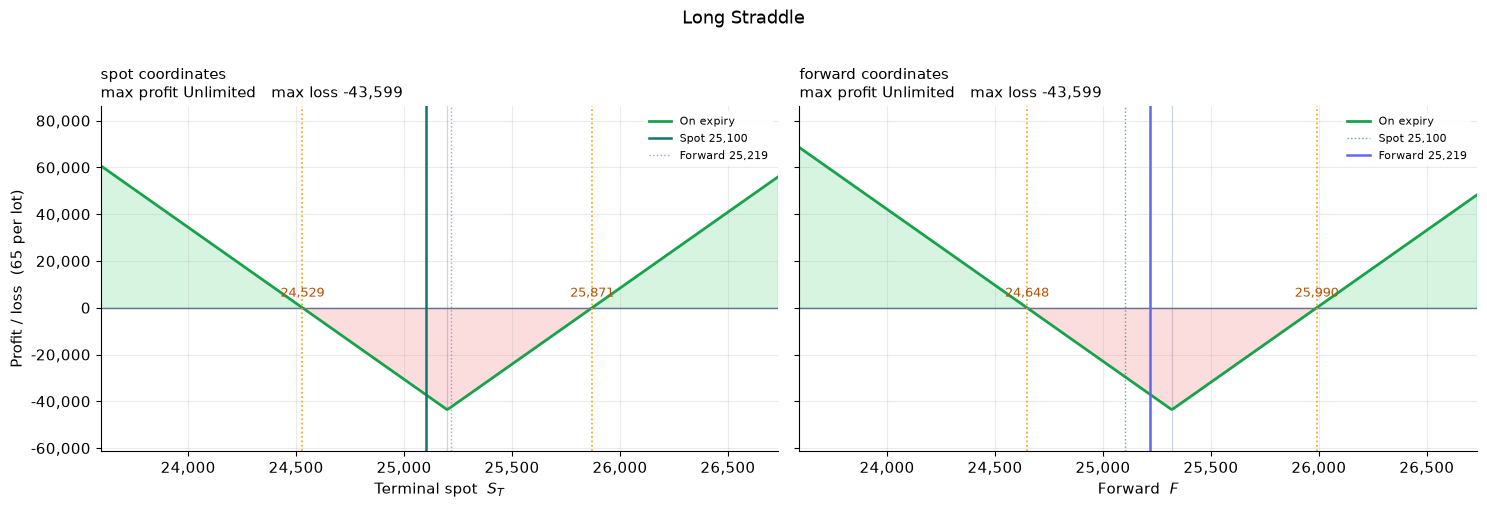

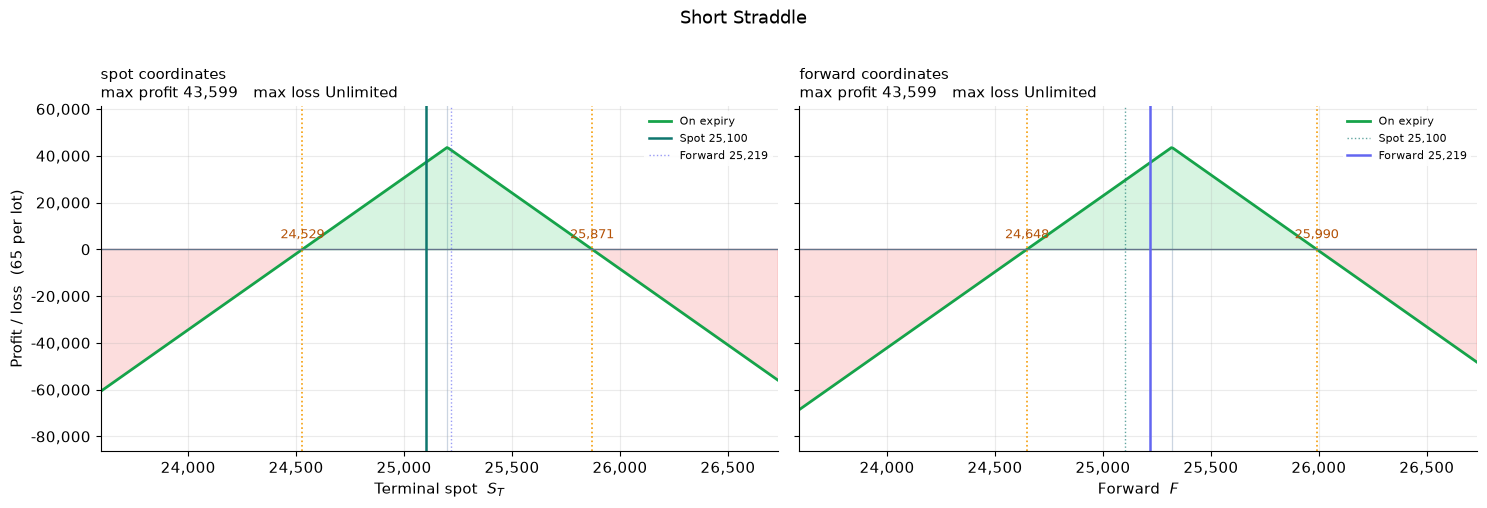

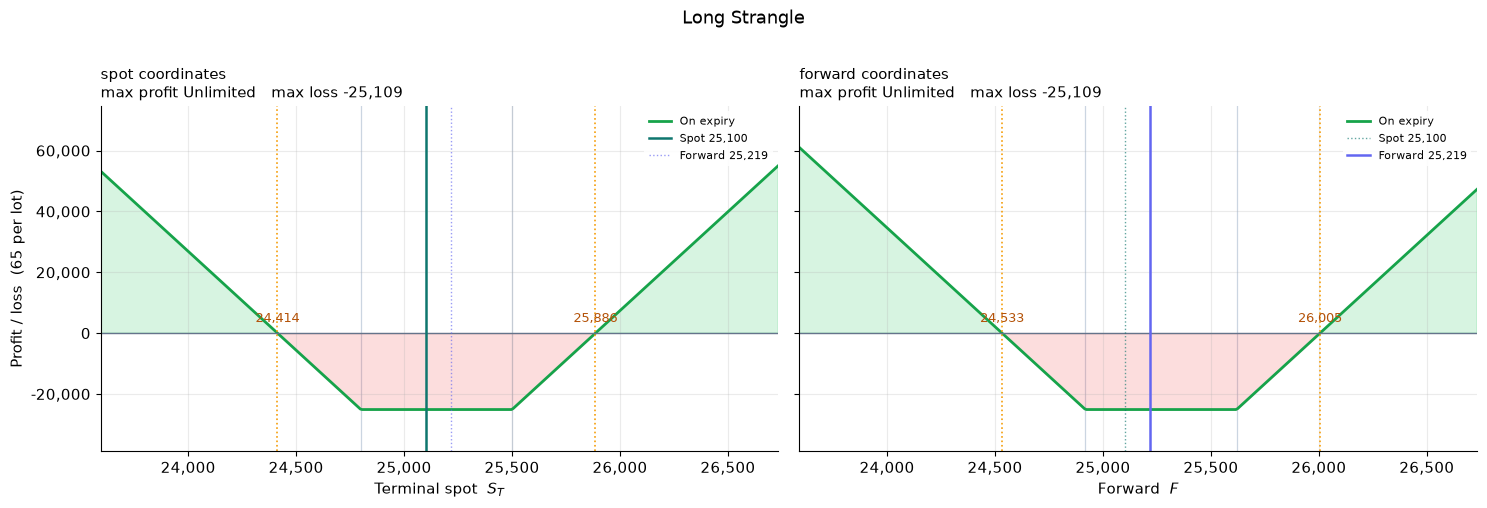

In [13]:
for name in ["Long Straddle", "Short Straddle", "Long Strangle"]:
    plot_pair(name)

### Vertical spreads — credit and debit

Two legs, same type, same expiry, different strikes $K_{\text{lo}} < K_{\text{hi}}$, opposite signs.
Every call is matched by a call and every put by a put, so

$$s_{\text{left}} = s_{\text{right}} = 0$$

Both tails flat: **defined risk on both sides**, with no wings to buy. The whole range is the width,

$$\text{max profit} - \text{max loss} = wL, \qquad w = K_{\text{hi}} - K_{\text{lo}}$$

and the premium decides where inside that range zero sits:

$$\textbf{credit:}\quad \text{max profit} = \text{credit}, \quad \text{max loss} = \text{credit} - wL$$
$$\textbf{debit:}\quad \text{max loss} = -\,\text{debit}, \quad \text{max profit} = wL - \text{debit}$$

$w$ is a difference of strikes, so $b$ cancels: **the width relation is the same in both
coordinate systems**, and so are both caps.

One breakeven — the near strike moved by the premium per unit, then by the basis:

$$S_T^{*} = K_{\text{lo}} + \frac{|\text{net}|}{L} \;\;\text{(calls)}
\qquad
S_T^{*} = K_{\text{hi}} - \frac{|\text{net}|}{L} \;\;\text{(puts)}$$

$$F^{*} = K_{\text{lo}} + b + \frac{|\text{net}|}{L}
\qquad
F^{*} = K_{\text{hi}} + b - \frac{|\text{net}|}{L}$$

Here $w = 300$ on both sides of 25200, so $wL = 300 \times 65 = 19{,}500$.

**Bull Call Spread — debit.** Buy 25200 CE @ 344.05, sell 25500 CE @ 206.20.

$$\text{net} = (344.05 - 206.20) \times 65 = 137.85 \times 65 = 8{,}960.25 \quad\text{(debit)}$$
$$\text{max loss} = -8{,}960.25 \qquad \text{max profit} = 19{,}500 - 8{,}960.25 = 10{,}539.75$$
$$S_T^{*} = 25200 + 137.85 = 25{,}337.85 \;\longrightarrow\; F^{*} = 25{,}456.72$$

**Bear Call Spread — credit.** The same two strikes, signs reversed.

$$\text{credit} = 137.85 \times 65 = 8{,}960.25$$
$$\text{max profit} = 8{,}960.25 \qquad \text{max loss} = 8{,}960.25 - 19{,}500 = -10{,}539.75$$
$$S_T^{*} = 25{,}337.85 \;\longrightarrow\; F^{*} = 25{,}456.72$$

**Bull Put Spread — credit.** Sell 25200 PE @ 326.70, buy 24900 PE @ 208.05.

$$\text{credit} = (326.70 - 208.05) \times 65 = 118.65 \times 65 = 7{,}712.25$$
$$\text{max profit} = 7{,}712.25 \qquad \text{max loss} = 7{,}712.25 - 19{,}500 = -11{,}787.75$$
$$S_T^{*} = 25200 - 118.65 = 25{,}081.35 \;\longrightarrow\; F^{*} = 25{,}200.22$$

**Bear Put Spread — debit.** The same two strikes, signs reversed.

$$\text{debit} = 7{,}712.25$$
$$\text{max loss} = -7{,}712.25 \qquad \text{max profit} = 19{,}500 - 7{,}712.25 = 11{,}787.75$$
$$S_T^{*} = 25{,}081.35 \;\longrightarrow\; F^{*} = 25{,}200.22$$

Each credit/debit pair is an exact mirror: same $|\text{net}|$, same breakeven, caps swapped.
Selling a spread is buying the opposite one.

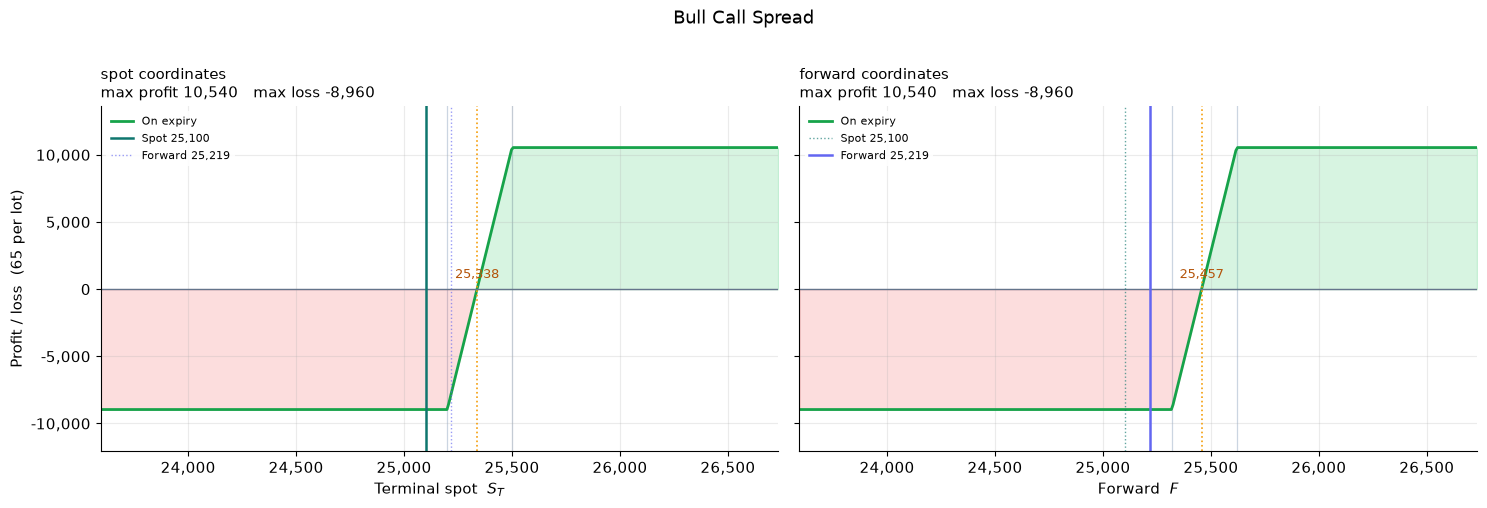

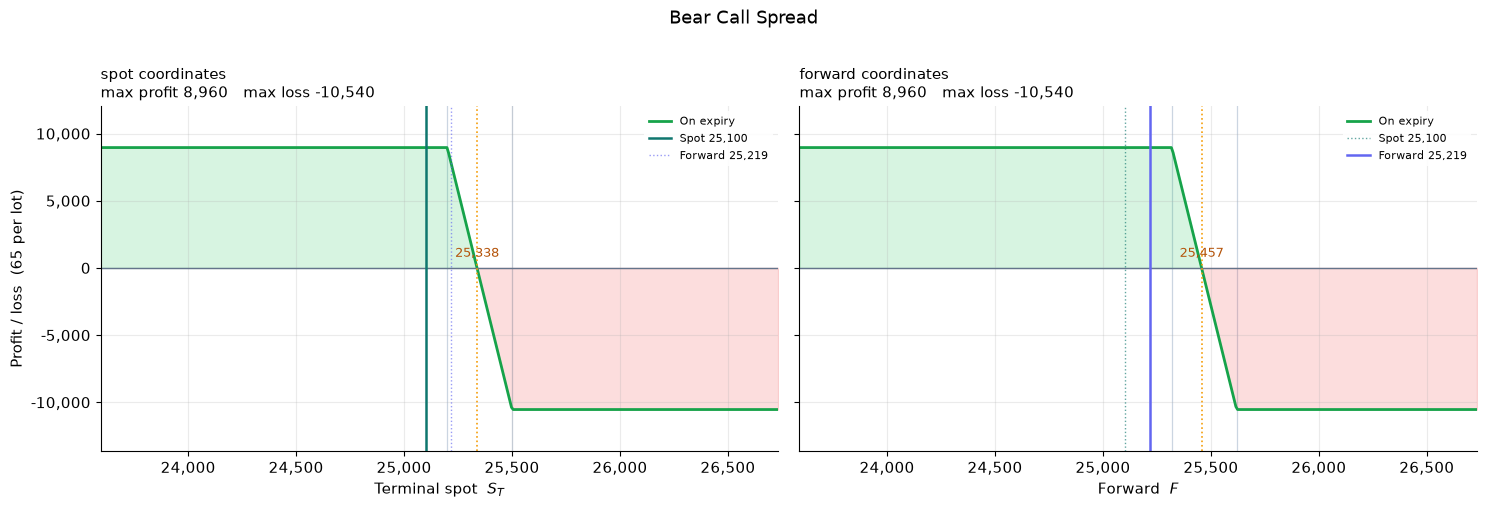

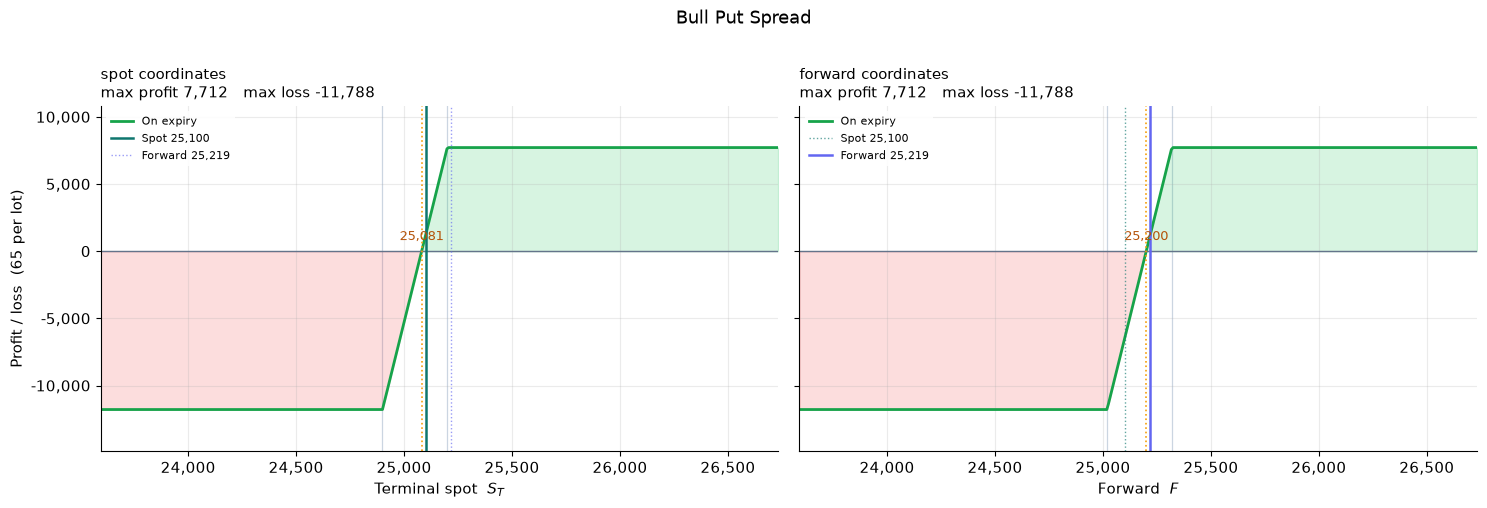

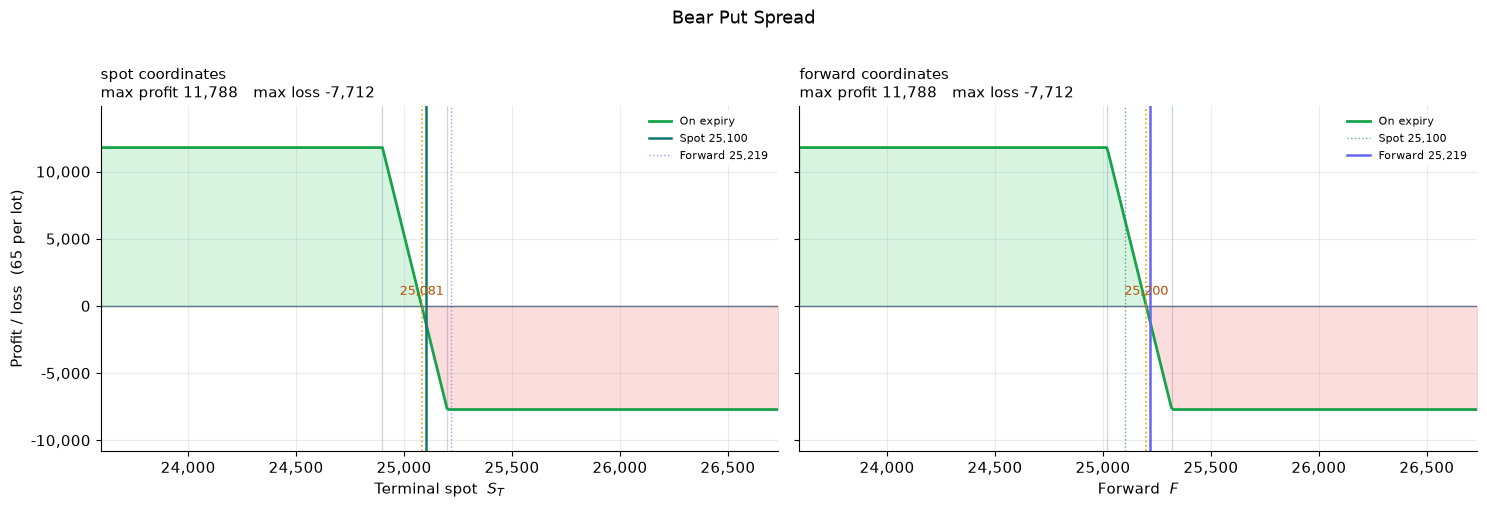

In [14]:
SPREADS = ["Bull Call Spread", "Bear Call Spread", "Bull Put Spread", "Bear Put Spread"]

for name in SPREADS:
    plot_pair(name)

#### Spread caps against the arithmetic

Every claim above, asserted against the engine in **both** coordinate systems — the width relation,
the credit and debit caps, and the breakeven. The caps and the width are framing-independent; the
breakeven formula picks up $b$. These fail the notebook, and the `execute` CI job, if the engine
ever disagrees.

In [15]:
for framing in FRAMINGS:
    print(f"{framing.name} coordinates")
    for name in SPREADS:
        legs = STRATEGIES[name]
        m = metrics_in(legs, framing, LOT_SIZE)
        k_lo, k_hi = sorted(leg.strike for leg in legs)
        w = k_hi - k_lo
        span = w * LOT_SIZE
        net = m["net_premium"]

        assert m["left_slope"] == 0 and m["right_slope"] == 0, f"{name} has an open tail"
        assert abs((m["max_profit"] - m["max_loss"]) - span) < 1e-6, f"{name}: range != w x lot"

        if net < 0:
            credit, kind = -net, "credit"
            assert abs(m["max_profit"] - credit) < 1e-6, f"{name}: max profit != credit"
            assert abs(m["max_loss"] - (credit - span)) < 1e-6, f"{name}: max loss != credit - wL"
        else:
            kind = "debit"
            assert abs(m["max_loss"] + net) < 1e-6, f"{name}: max loss != -debit"
            assert abs(m["max_profit"] - (span - net)) < 1e-6, f"{name}: max profit != wL - debit"

        calls = all(leg.is_call for leg in legs)
        near = k_lo + framing.shift if calls else k_hi + framing.shift
        expected_be = near + abs(net) / LOT_SIZE if calls else near - abs(net) / LOT_SIZE
        assert len(m["breakevens"]) == 1, f"{name}: expected exactly one breakeven"
        assert abs(m["breakevens"][0] - expected_be) < 0.01, f"{name}: breakeven off formula"

        print(f"  {name:<18} {k_lo + framing.shift:,.2f}/{k_hi + framing.shift:,.2f}  "
              f"w {w:>3,.0f} x {LOT_SIZE} = {span:>7,.0f}   {abs(net):>9,.2f} {kind:<6}  "
              f"max profit {m['max_profit']:>10,.2f}   max loss {m['max_loss']:>11,.2f}   "
              f"breakeven {m['breakevens'][0]:,.2f}")
    print()

spot coordinates
  Bull Call Spread   25,200.00/25,500.00  w 300 x 65 =  19,500    8,960.25 debit   max profit  10,539.75   max loss   -8,960.25   breakeven 25,337.85
  Bear Call Spread   25,200.00/25,500.00  w 300 x 65 =  19,500    8,960.25 credit  max profit   8,960.25   max loss  -10,539.75   breakeven 25,337.85
  Bull Put Spread    24,900.00/25,200.00  w 300 x 65 =  19,500    7,712.25 credit  max profit   7,712.25   max loss  -11,787.75   breakeven 25,081.35
  Bear Put Spread    24,900.00/25,200.00  w 300 x 65 =  19,500    7,712.25 debit   max profit  11,787.75   max loss   -7,712.25   breakeven 25,081.35

forward coordinates
  Bull Call Spread   25,318.87/25,618.87  w 300 x 65 =  19,500    8,960.25 debit   max profit  10,539.75   max loss   -8,960.25   breakeven 25,456.72
  Bear Call Spread   25,318.87/25,618.87  w 300 x 65 =  19,500    8,960.25 credit  max profit   8,960.25   max loss  -10,539.75   breakeven 25,456.72
  Bull Put Spread    25,018.87/25,318.87  w 300 x 65 =  19,500

### Iron condor and iron fly

Wings bought beyond each short leg turn what would otherwise be an unbounded loss into a known one.

- **Iron fly** — short ATM straddle, wings 300 points out.
- **Iron condor** — short strangle 300 out, wings 600 out.

Four legs each, no new code.

**Iron condor** — sell 25500 CE @ 206.20 and 24900 PE @ 208.05, buy 25800 CE @ 115.60 and
24600 PE @ 130.20.

$$-206.20 - 208.05 + 115.60 + 130.20 = -168.45
\;\Rightarrow\; -168.45 \times 65 = -10{,}949.25 \quad \text{(credit)}$$

Both wings bought $\Rightarrow s_{\text{left}} = s_{\text{right}} = 0$: both tails flat, both caps
finite.

$$\text{max profit} = \text{credit} = 10{,}949.25$$

$$\text{max loss} = \text{credit} - wL = 10{,}949.25 - 300 \times 65 = -8{,}550.75$$

The credit erodes outward from each short strike:

$$24900 - 168.45 = 24{,}731.55 \qquad 25500 + 168.45 = 25{,}668.45$$

In forward coordinates:

$$24{,}731.55 \,/\, 25{,}668.45 \;\;\longrightarrow\;\; 24{,}850.42 \,/\, 25{,}787.32$$

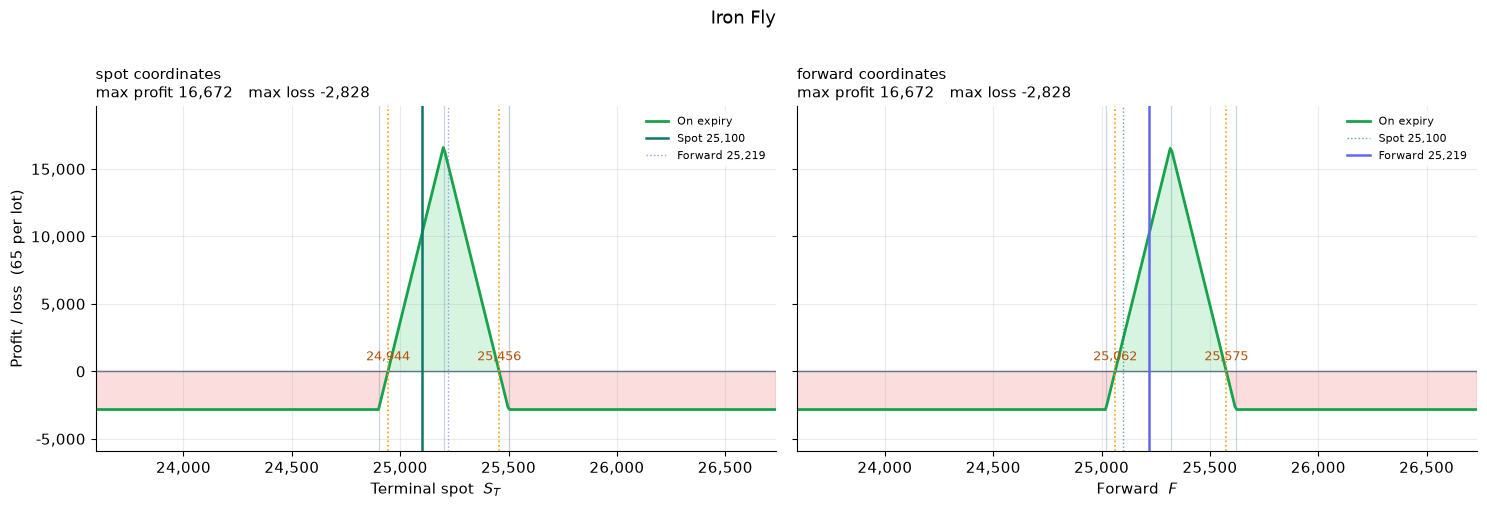

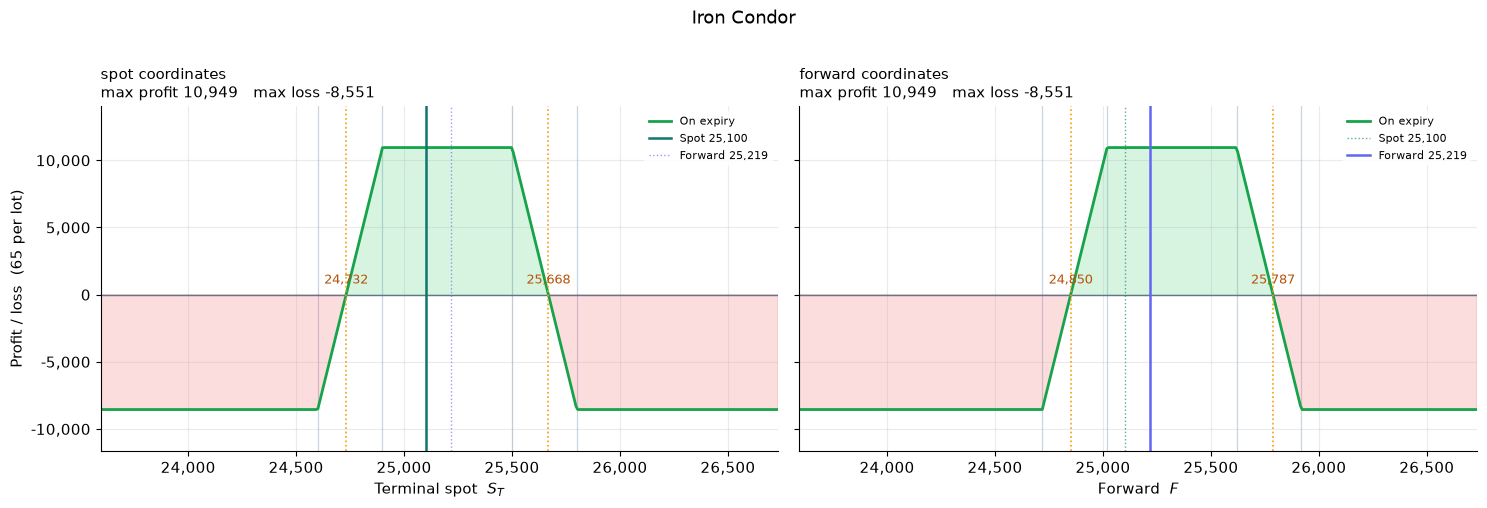

In [16]:
for name in ["Iron Fly", "Iron Condor"]:
    plot_pair(name)

#### Caps against the arithmetic

For a credit structure with both tails flat, the caps are forced by the wings:

$$\text{max profit} = \text{credit}
\qquad
\text{max loss} = \text{credit} - w_{\max} L,
\qquad w_{\max} = \max\bigl(w_{\text{left}},\, w_{\text{right}}\bigr)$$

The **wider** wing sets the loss. The two tails are flat at $\text{credit} - w_{\text{left}}L$ and
$\text{credit} - w_{\text{right}}L$, and the cap is the lower of them.

At this anchor both structures come out symmetric, so $w_{\max}$ collapses to plain $w$ and the
general form looks like decoration. **It is not.** The chain has gaps: 25,400 CE is not quoted, so
a fly built at the *spot*-nearest strike instead lands its call wing 400 points out against 300 on
the put side, and $\text{credit} - wL$ would be wrong. The cell below prints those widths as
evidence — that fly is not a position drawn anywhere here, only a demonstration that the
generalisation is load-bearing.

In [17]:
# Not a position we draw - evidence that w_max is load-bearing.
_, spot_strikes = build_strategies(min(both_sides, key=lambda k: abs(k - SPOT)))
print(f"a fly built at the spot-nearest strike {spot_strikes['atm']:,.0f} would have wings "
      f"{spot_strikes['atm'] - spot_strikes['fly_put']:,.0f} put / "
      f"{spot_strikes['fly_call'] - spot_strikes['atm']:,.0f} call   (25,400 CE is not quoted)\n")

for framing in FRAMINGS:
    print(f"{framing.name} coordinates")
    for name, put_width, call_width in [
        ("Iron Fly",    STRIKES["atm"] - STRIKES["fly_put"],
                        STRIKES["fly_call"] - STRIKES["atm"]),
        ("Iron Condor", STRIKES["fly_put"] - STRIKES["con_put"],
                        STRIKES["con_call"] - STRIKES["fly_call"]),
    ]:
        m = metrics_in(STRATEGIES[name], framing, LOT_SIZE)

        credit = -m["net_premium"]                   # net_premium is negative when we are paid
        w_max = max(put_width, call_width)
        risk = w_max * LOT_SIZE
        expected_loss = credit - risk

        assert m["left_slope"] == 0 and m["right_slope"] == 0, f"{name} has an open tail"
        assert abs(m["max_profit"] - credit) < 1e-6, f"{name}: max profit != credit"
        assert abs(m["max_loss"] - expected_loss) < 1e-6, f"{name}: max loss != credit - w_max x lot"

        symmetry = "symmetric" if put_width == call_width else "ASYMMETRIC"
        print(f"  {name}")
        print(f"    wings        {put_width:,.0f} put / {call_width:,.0f} call   ({symmetry}), "
              f"w_max {w_max:,.0f} x {LOT_SIZE} = {risk:,.2f}")
        print(f"    net credit   {credit:,.2f}")
        print(f"    max profit   {m['max_profit']:,.2f}   = credit")
        print(f"    max loss     {m['max_loss']:,.2f}   = credit - w_max x lot")
        print(f"    breakevens   {fmt_bes(m['breakevens'])}")
    print()

a fly built at the spot-nearest strike 25,100 would have wings 300 put / 400 call   (25,400 CE is not quoted)

spot coordinates
  Iron Fly
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   16,672.50
    max profit   16,672.50   = credit
    max loss     -2,827.50   = credit - w_max x lot
    breakevens   24,943.50, 25,456.50
  Iron Condor
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   10,949.25
    max profit   10,949.25   = credit
    max loss     -8,550.75   = credit - w_max x lot
    breakevens   24,731.55, 25,668.45

forward coordinates
  Iron Fly
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   16,672.50
    max profit   16,672.50   = credit
    max loss     -2,827.50   = credit - w_max x lot
    breakevens   25,062.37, 25,575.37
  Iron Condor
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   10,949.

### Naked call and put

The building blocks. One leg each, same two functions.

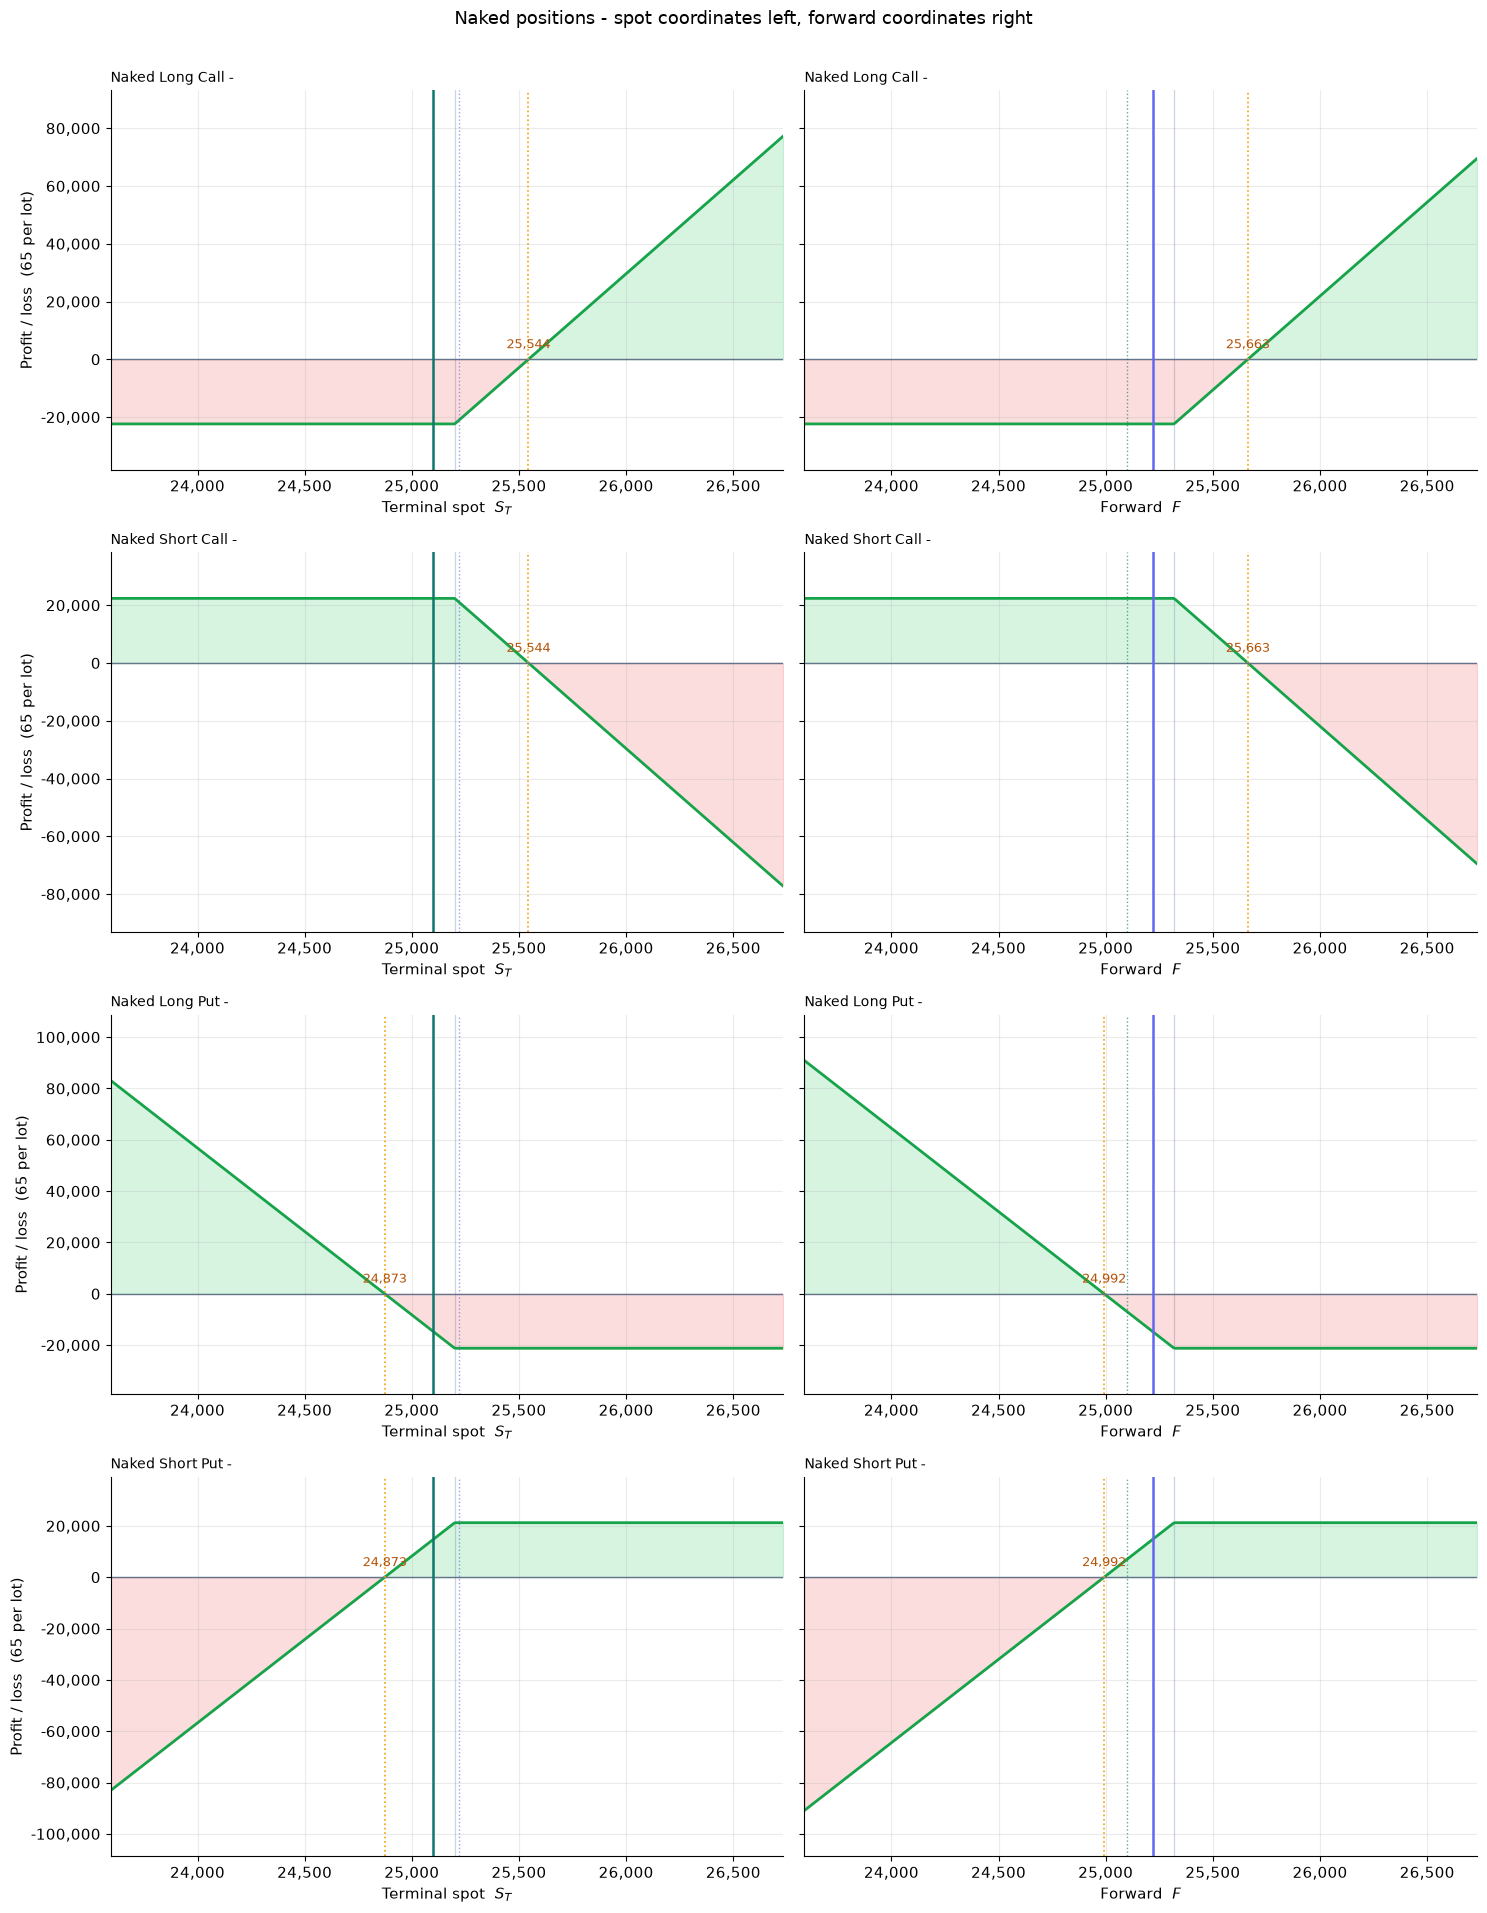

In [18]:
NAKED = ["Naked Long Call", "Naked Short Call", "Naked Long Put", "Naked Short Put"]

fig, axes = plt.subplots(4, 2, figsize=(15, 19), sharey="row")
for row, name in zip(axes, NAKED):
    for ax, framing in zip(row, FRAMINGS):
        plot_strategy(name, framing, ax=ax)
        ax.legend().remove()
        ax.set_title(f"{name} - {ax.get_title()}", fontsize=10, loc="left")
    row[1].set_ylabel("")
fig.suptitle("Naked positions - spot coordinates left, forward coordinates right",
             fontsize=13, y=1.005)
fig.tight_layout()
plt.show()

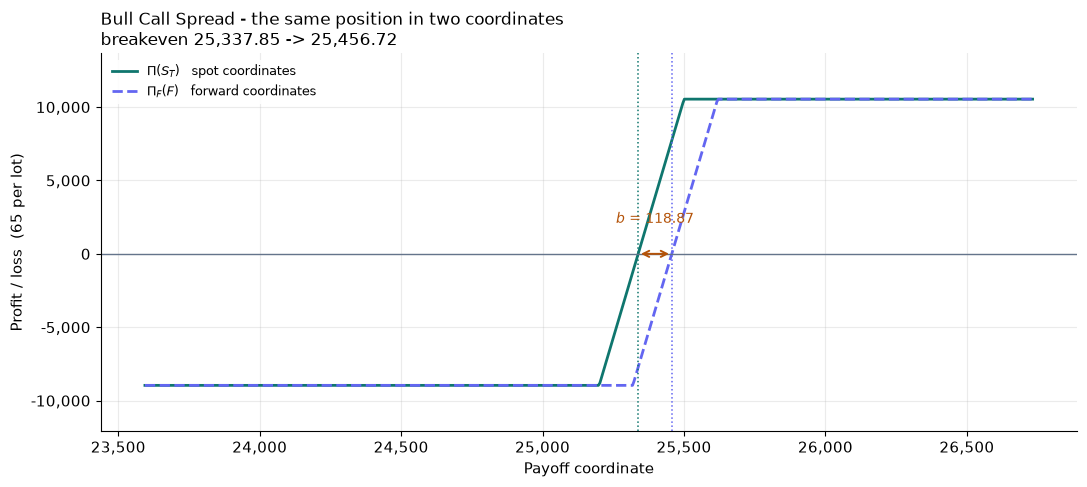

breakeven  spot 25,337.85   forward 25,456.72   difference +118.87   basis +118.87


In [19]:
# The pair plots above already share a frame, so the shift is visible there. This puts both
# curves on the *same* axes to measure it: the gap between the two breakevens is exactly b.
legs = STRATEGIES["Bull Call Spread"]
grid = np.linspace(SPOT * 0.94, FORWARD * 1.06, 600)

spot_curve = payoff_at_expiry(grid, legs, LOT_SIZE)
fwd_curve = payoff_in(grid, legs, FORWARD_FRAMING, LOT_SIZE)

assert np.allclose(fwd_curve, payoff_at_expiry(grid - BASIS, legs, LOT_SIZE)), \
    "the forward curve is not a pure translation of the spot curve"

be_s = metrics_in(legs, SPOT_FRAMING, LOT_SIZE)["breakevens"][0]
be_f = metrics_in(legs, FORWARD_FRAMING, LOT_SIZE)["breakevens"][0]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(grid, spot_curve, color="#0f766e", lw=2.0, label=r"$\Pi(S_T)$   spot coordinates")
ax.plot(grid, fwd_curve, color="#6366f1", lw=2.0, ls="--",
        label=r"$\Pi_F(F)$   forward coordinates")
ax.axhline(0, color="#64748b", lw=1)

ax.annotate("", xy=(be_f, 0), xytext=(be_s, 0),
            arrowprops=dict(arrowstyle="<->", color="#b45309", lw=1.4))
ax.annotate(f"$b$ = {BASIS:,.2f}", ((be_s + be_f) / 2, 0), textcoords="offset points",
            xytext=(0, 22), ha="center", fontsize=10, color="#b45309")
for be, colour in ((be_s, "#0f766e"), (be_f, "#6366f1")):
    ax.axvline(be, color=colour, ls=":", lw=1.1)

ax.set_title(f"Bull Call Spread - the same position in two coordinates\n"
             f"breakeven {be_s:,.2f} -> {be_f:,.2f}", fontsize=12, loc="left")
ax.set_xlabel("Payoff coordinate")
ax.set_ylabel(f"Profit / loss  ({LOT_SIZE} per lot)")
ax.margins(y=0.16)
ax.legend(loc="best", fontsize=9, framealpha=0.9, edgecolor="none", facecolor="white")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:,.0f}")
plt.tight_layout()
plt.show()

print(f"breakeven  spot {be_s:,.2f}   forward {be_f:,.2f}   difference {be_f - be_s:+.2f}"
      f"   basis {BASIS:+.2f}")

## 9. Greeks

The payoff chart says what a position settles to. It says nothing about where the risk comes
from between now and then. That is what the Greeks are for, and this section computes four of
them — from the same Black-76 the rest of the notebook uses, on the forward, never on a spot.

| | reads as |
|---|---|
| $\Delta$ | rupees gained per point the forward rises |
| $\Gamma$ | how much that $\Delta$ itself moves, per point |
| $\nu$ | rupees per **volatility point** — a 1% move, not a 100% move |
| $\Theta$ | rupees after one session passes and nothing else moves |

Every figure in this section is **per contract, never per lot**. That is the unit the source's
Greek columns are in, so the grading below is a direct comparison rather than a comparison with a
factor of 65 hidden in it — and it is deliberately the opposite convention to §§6–8, where the
payoff is drawn per lot. A payoff is a rupee amount for a *position*; a Greek is a property of the
*contract*. Multiply by $L = 65$ when one lot's exposure is what is wanted.

Everything below is priced at the **observed** moment: $\hat F$ and $D$ from §3's parity fit,
$\sigma$ from §4's Newton solve. All three are the notebook's own work, so nothing pre-solved is
fed in — the source's Greek columns appear only on the right-hand side of a subtraction.

### Why this needs no new convention

[#27](https://github.com/lalitkarthik/convex-hedge-payoff/issues/27) makes the point that keeps
this section cheap: there is **no hypothetical spot to convert and no volatility to roll
forward**, so it depends on neither
[#13](https://github.com/lalitkarthik/convex-hedge-payoff/issues/13) (the spot-to-forward rule)
nor [#8](https://github.com/lalitkarthik/convex-hedge-payoff/issues/8) (target-date volatility).
Both stay open and both stay unanswered here. §2's constant-basis convention was a **charting**
choice for the expiry line; it is not a pricing rule and is not used below.

### The conventions are the source's, and they are not all textbook

| | |
|---|---|
| $\Delta$, $\Gamma$ | **undiscounted** — the true $\partial V/\partial \hat F$ is $D\,N(d_1)$; the $D$ is dropped |
| $\nu$ | **discounted**, and divided by 100 — per volatility *point* |
| $\Theta$ | **a one-trading-day repricing**, not $\partial V/\partial t$ |

The mixture is deliberate and inherited, not a slip: $\nu$ carries the discount factor and
$\Delta$ does not. It is worth saying out loud, because the first reader to notice will assume it
is a bug. These are the conventions `src/payoff/pricing.py` is graded against in CI, and a
convention that reads oddly is a labelling problem, not a maths problem.

In [20]:
# One sigma per strike, from section 4's own solve. The source shares one volatility between the
# call and the put at a strike - it inverts the out-of-the-money leg and copies the answer to the
# in-the-money twin, whose last print is stale - so a per-strike lookup is the right shape.
VOL_AT = {float(k): float(v) for k, v in zip(SLICE.strike, SLICE.iv)}

used = sorted({leg.strike for legs in STRATEGIES.values() for leg in legs})
missing = [k for k in used if k not in VOL_AT]
assert not missing, f"no solved sigma at {missing} - section 4 did not invert these strikes"

# Leg.iv carries the chain's own volatility. Keeping it and checking it beats deleting it: the
# duplicate becomes a grade of section 4's solver at every strike a structure touches.
for legs in STRATEGIES.values():
    for leg in legs:
        assert abs(leg.iv - VOL_AT[leg.strike]) < 1e-9, f"sigma disagrees at {leg.strike:,.0f}"

unsolved = sorted(set(snap.strike.astype(float)) - set(VOL_AT))

print(f"solved sigma at {len(VOL_AT)} of {snap.strike.nunique()} snapshot strikes")
print(f"  not solved   {'  '.join(f'{k:,.0f}' for k in unsolved)}")
print("               single-sided quotes on the wrong side of the forward - no OTM leg to invert")
print(f"  in play      {'  '.join(f'{k:,.0f}' for k in used)}")
print(f"               all {len(used)} covered")

solved sigma at 46 of 49 snapshot strikes
  not solved   24,850  25,400  25,450
               single-sided quotes on the wrong side of the forward - no OTM leg to invert
  in play      24,600  24,800  24,900  25,200  25,500  25,800
               all 6 covered


### One leg

$d_1$ and $d_2$ are §4's, unchanged:

$$d_1 = \frac{\ln(\hat F/K) + \tfrac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and then, with $N$ the standard normal CDF and $n$ its density:

$$\Delta = N(d_1) \;\;\text{(call)}, \qquad \Delta = N(d_1) - 1 \;\;\text{(put)}$$

$$\Gamma = \frac{n(d_1)}{\hat F \, \sigma \sqrt{T}}, \qquad
  \nu = \frac{D \, \hat F \, n(d_1) \sqrt{T}}{100}$$

$\Gamma$ and $\nu$ depend on the strike only through $d_1$, which a call and a put at one strike
share. **They are identical for the two.** Only $\Delta$ knows which side it is on, and the two
$\Delta$s differ by exactly 1 — which is put-call parity, and is used as a check further down.

#### $\Theta$ is a repricing, not a derivative

$$\Theta = V\!\left(T - \tfrac{1}{252},\; D_{\text{next}}\right) - V(T, D),
  \qquad D_{\text{next}} = e^{-r\left(T - \frac{1}{252}\right)}, \qquad r = -\frac{\ln D}{T}$$

What the contract is worth after one session has passed and nothing else has moved. Two reasons
this rather than the analytic $\partial V/\partial t$: it is the number a trader reads $\Theta$
as, and it is the one the source actually ships. The analytic form is measurably wrong against
this data — quantified two cells below, rather than asserted here.

The rate is reconstructed from $D$ only to roll the discount one day. It never enters the
interface and never leaves the function: per **ADR-0001** the core takes a forward and a discount
factor, never a spot and a rate, because the implied rate runs from 0.9% to 28.4% across the
dataset and diverges as $T \to 0$.

In [21]:
GREEKS = ("delta", "gamma", "vega", "theta")


def leg_greeks(leg, forward, T, vol, discount):
    """The four main Greeks for one contract, in the source's conventions.

    Per-contract and unsigned by direction, so the number is directly comparable to a row of
    the chain. Direction and quantity belong to structure_greeks, not here.
    """
    forward = np.asarray(forward, float)
    v = vol * np.sqrt(T)
    d1 = (np.log(forward / leg.strike) + 0.5 * vol**2 * T) / v

    price = black76_price(forward, leg.strike, T, vol, discount, is_call=leg.is_call)

    # Theta by repricing one session on, not dV/dt. The rate is reconstructed only to roll the
    # discount and never leaves this function (ADR-0001).
    rate = -np.log(discount) / T
    T_next = max(T - 1 / TRADING_DAYS_PER_YEAR, 0.0)
    repriced = black76_price(forward, leg.strike, T_next, vol,
                             np.exp(-rate * T_next), is_call=leg.is_call)

    return {
        "delta": norm.cdf(d1) if leg.is_call else norm.cdf(d1) - 1.0,   # undiscounted
        "gamma": norm.pdf(d1) / (forward * v),                          # undiscounted
        "vega": discount * forward * norm.pdf(d1) * np.sqrt(T) / 100,   # per volatility point
        "theta": repriced - price,                                      # one trading day
    }


# The formulas above are written out so both of us can read them. That is only defensible
# because they are graded against the engine, which CI already grades against the source on all
# 23,581 rows - so src/payoff/pricing.py is the referee, not a second opinion.
for legs in STRATEGIES.values():
    for leg in legs:
        mine = leg_greeks(leg, FORWARD, T, VOL_AT[leg.strike], DISCOUNT)
        theirs = black76_greeks(FORWARD, leg.strike, T, VOL_AT[leg.strike],
                                DISCOUNT, is_call=leg.is_call)
        for g in GREEKS:
            assert abs(float(mine[g]) - float(theirs[g])) < 1e-12, f"{leg} {g}"

print(f"leg_greeks agrees with black76_greeks to < 1e-12 on every leg of all "
      f"{len(STRATEGIES)} structures\n")

# The at-the-money pair, in full, so the arithmetic above can be checked by hand.
hdr = f"{'leg':<14}{'sigma':>9}{'delta':>11}{'gamma':>12}{'vega':>10}{'theta':>10}"
print(hdr)
print("-" * len(hdr))
atm_pair = {}
for option_type in ("CE", "PE"):
    probe = Leg(ATM, option_type, +1, 0.0, VOL_AT[ATM])
    atm_pair[option_type] = leg_greeks(probe, FORWARD, T, VOL_AT[ATM], DISCOUNT)
    g = atm_pair[option_type]
    print(f"{ATM:,.0f} {option_type:<8}{VOL_AT[ATM]:>9.4f}{float(g['delta']):>11.6f}"
          f"{float(g['gamma']):>12.8f}{float(g['vega']):>10.4f}{float(g['theta']):>10.4f}")

delta_gap = float(atm_pair["CE"]["delta"]) - float(atm_pair["PE"]["delta"])
print(f"\ngamma and vega are identical for the two - they depend on the strike only through d1.")
print(f"the deltas differ by exactly {delta_gap:.10f}, which is put-call parity.")
assert abs(delta_gap - 1.0) < 1e-12

leg_greeks agrees with black76_greeks to < 1e-12 on every leg of all 13 structures

leg               sigma      delta       gamma      vega     theta
------------------------------------------------------------------
25,200 CE         0.1643   0.515699  0.00046987   20.4453  -16.1002
25,200 PE         0.1643  -0.484301  0.00046987   20.4453  -16.1119

gamma and vega are identical for the two - they depend on the strike only through d1.
the deltas differ by exactly 1.0000000000, which is put-call parity.


### Against the source Greeks

`Data/sample/chain_2026-01-27.parquet` ships `delta`, `gamma`, `vega` and `theta` alongside the
prices. Per `CONTEXT.md` they are a **test oracle, never an input** — so they are graded against,
and the grading is the point of the project rather than a formality.

The comparison below is stricter than it looks. It does not feed the source's `forward`,
`discount` or `iv` back in. It uses $\hat F$ from §3's parity fit, $D$ from the same fit and
$\sigma$ from §4's Newton solve, so a single wrong step anywhere in §§3–4 would show up here.

Graded over every snapshot leg whose strike §4 solved — both sides where both are quoted, wings
included, not only the six strikes the structures use.

In [22]:
gradeable = snap[snap.strike.astype(float).isin(VOL_AT)]

worst = dict.fromkeys(GREEKS, 0.0)
for _, row in gradeable.iterrows():
    sigma = VOL_AT[float(row.strike)]
    probe = Leg(float(row.strike), row.option_type, +1, float(row.last), sigma)
    mine = leg_greeks(probe, FORWARD, T, sigma, DISCOUNT)
    for g in GREEKS:
        worst[g] = max(worst[g], abs(float(mine[g]) - float(row[g])))

print(f"legs graded   {len(gradeable)}   across {gradeable.strike.nunique()} strikes")
print(f"inputs        F_hat and D from section 3, sigma from section 4 - nothing pre-solved\n")
print(f"{'greek':<10}{'worst absolute drift':>24}")
for g in GREEKS:
    print(f"{g:<10}{worst[g]:>24.3e}")

# A tripwire for a changed model, not a threshold tuned to pass: the measured drift is two
# orders of magnitude below it.
assert max(worst.values()) < 1e-8, f"drift against the source: {worst}"

legs graded   55   across 46 strikes
inputs        F_hat and D from section 3, sigma from section 4 - nothing pre-solved

greek         worst absolute drift
delta                    3.533e-12
gamma                    5.928e-15
vega                     3.891e-10
theta                    4.133e-10


#### The $\Theta$ trap

The textbook Black-76 theta is a derivative, not a difference:

$$\Theta_{\text{analytic}} = -\frac{D \, \hat F \, n(d_1) \, \sigma}{2\sqrt{T}} \;+\; r\,V$$

per year, which one then divides by 252 to get a session. It is the obvious thing to write, and
against this data it is **wrong** — quietly.

The cell below measures it. The miss is largest at the money and shrinks into the wings, it has
the same sign everywhere, and at its worst it is about 2.5% of the figure. Nothing about it looks
anomalous on a chart or in a table; there is no outlier to notice, no `NaN`, no exception. A
Greeks table built on it would simply understate the decay of every near-the-money position, all
day, by a couple of percent.

That is exactly the failure mode `CONTRIBUTING.md` and ADR-0001 exist to catch — a number that is
plausible, consistent and wrong. So the notebook computes it, prints it beside the repricing
form, and **asserts that it disagrees**. If someone later "simplifies" `leg_greeks` to the
analytic theta, this cell fails instead of the charts drifting.

In [23]:
def analytic_theta_per_session(leg, forward, T, vol, discount):
    """Textbook dV/dt, divided down to one session. Computed to be rejected, never used."""
    v = vol * np.sqrt(T)
    d1 = (np.log(forward / leg.strike) + 0.5 * vol**2 * T) / v
    value = float(black76_price(forward, leg.strike, T, vol, discount, is_call=leg.is_call))
    rate = -np.log(discount) / T
    per_year = -discount * forward * norm.pdf(d1) * vol / (2 * np.sqrt(T)) + rate * value
    return per_year / TRADING_DAYS_PER_YEAR


rows = []
for _, row in gradeable.iterrows():
    sigma = VOL_AT[float(row.strike)]
    probe = Leg(float(row.strike), row.option_type, +1, float(row.last), sigma)
    rows.append((
        float(row.strike), row.option_type,
        float(leg_greeks(probe, FORWARD, T, sigma, DISCOUNT)["theta"]),
        analytic_theta_per_session(probe, FORWARD, T, sigma, DISCOUNT),
        float(row.theta),
    ))

hdr = f"{'strike':>9}{'type':>5}{'repricing':>12}{'analytic':>12}{'source':>12}{'analytic miss':>16}"
print(hdr)
print("-" * len(hdr))
for strike, option_type, repriced, analytic, source in sorted(rows, key=lambda r: -abs(r[3] - r[4]))[:2]:
    print(f"{strike:>9,.0f}{option_type:>5}{repriced:>12.4f}{analytic:>12.4f}{source:>12.4f}"
          f"{analytic - source:>+16.4f}")
for strike, option_type, repriced, analytic, source in sorted(rows, key=lambda r: abs(r[3] - r[4]))[:1]:
    print(f"{strike:>9,.0f}{option_type:>5}{repriced:>12.4f}{analytic:>12.4f}{source:>12.4f}"
          f"{analytic - source:>+16.4f}")

analytic_miss = max(abs(a - s) for _, _, _, a, s in rows)
repricing_miss = max(abs(r - s) for _, _, r, _, s in rows)
print(f"\nworst miss   analytic {analytic_miss:.4f}   repricing {repricing_miss:.3e}")
print(f"at the money the analytic form is out by "
      f"{100 * analytic_miss / abs(min(s for _, _, _, _, s in rows)):.2f}% of the figure")

assert analytic_miss > 0.4, "the analytic theta has stopped disagreeing - check the convention"
assert repricing_miss < 1e-8, "the repricing theta no longer matches the source"

   strike type   repricing    analytic      source   analytic miss
------------------------------------------------------------------
   25,200   PE    -16.1119    -15.7064    -16.1119         +0.4055
   25,200   CE    -16.1002    -15.6946    -16.1002         +0.4055
   26,050   CE     -9.2985     -9.3031     -9.2985         -0.0047

worst miss   analytic 0.4055   repricing 4.133e-10
at the money the analytic form is out by 2.52% of the figure


### A structure

Every Greek is **extensive** — it scales with position size and adds across legs — so combining
them needs no more machinery than the payoff did:

$$G \;=\; \sum_{i=1}^{n} d_i \, q_i \, g_i$$

Set that beside §6's payoff, which is the same sum over a different quantity:

$$\Pi(S_T) \;=\; L \sum_{i=1}^{n} d_i \, q_i \bigl(V_i(S_T) - e_i\bigr)$$

One sum, any number of legs, no special cases. Two things fall out rather than being enforced:

- **A short leg reports the negated Greek of the equivalent long leg**, because $d_i = -1$ is the
  only difference between them. That is one of #27's acceptance criteria, and it is a consequence
  here rather than a rule.
- **There is no $L$ here, and that asymmetry is the point.** The payoff carries the lot size
  because it is a rupee amount for a position; a Greek is a property of the contract, so it is
  reported for one. The units are $\Delta$ in rupees per point of forward, $\nu$ in rupees per
  volatility point, $\Theta$ in rupees per session, $\Gamma$ in $\Delta$ per point — each per
  contract, and each scaled to a lot by one multiplication the caller owns.

In [24]:
def structure_greeks(legs, forward, T, discount):
    """Net exposure of a structure, per contract: sum_i d_i q_i g_i.

    The same shape as payoff_at_expiry. Every Greek is extensive, so aggregation is a weighted
    sum and there is nothing to branch on.
    """
    total = {g: np.zeros_like(np.asarray(forward, float)) for g in GREEKS}
    for leg in legs:
        g = leg_greeks(leg, forward, T, VOL_AT[leg.strike], discount)
        for name in GREEKS:
            total[name] = total[name] + leg.direction * leg.quantity * np.asarray(g[name], float)
    return total


# Where the risk comes from, not only what it nets to - the reason #27 asks for a per-leg row.
hdr = f"{'Iron Condor':<28}{'delta':>10}{'gamma':>12}{'vega':>10}{'theta':>11}"
print(hdr)
print("-" * len(hdr))
for leg in STRATEGIES["Iron Condor"]:
    g = structure_greeks([leg], FORWARD, T, DISCOUNT)
    print(f"  {leg!r:<26}{float(g['delta']):>10.4f}{float(g['gamma']):>12.7f}"
          f"{float(g['vega']):>10,.3f}{float(g['theta']):>11,.4f}")
total = structure_greeks(STRATEGIES["Iron Condor"], FORWARD, T, DISCOUNT)
print("-" * len(hdr))
print(f"  {'total':<26}{float(total['delta']):>10.4f}{float(total['gamma']):>12.7f}"
      f"{float(total['vega']):>10,.3f}{float(total['theta']):>11,.4f}")

Iron Condor                      delta       gamma      vega      theta
-----------------------------------------------------------------------
  S 1x 25500 CE @ 206.20       -0.3729  -0.0004614   -19.414    14.8083
  S 1x 24900 PE @ 208.05        0.3500  -0.0004246   -18.996    15.4040
  B 1x 25800 CE @ 115.60        0.2451   0.0003866    16.128   -12.1125
  B 1x 24600 PE @ 130.20       -0.2400   0.0003413    15.943   -13.4116
-----------------------------------------------------------------------
  total                        -0.0178  -0.0001580    -6.338     4.6882


In [25]:
EXPOSURE = {name: structure_greeks(legs, FORWARD, T, DISCOUNT)
            for name, legs in STRATEGIES.items()}

hdr = f"{'structure':<18}{'delta':>12}{'gamma':>14}{'vega':>12}{'theta':>12}"
print(hdr)
print("-" * len(hdr))
for name, g in EXPOSURE.items():
    print(f"{name:<18}{float(g['delta']):>12,.4f}{float(g['gamma']):>14.7f}"
          f"{float(g['vega']):>12,.3f}{float(g['theta']):>12,.4f}")

structure                delta         gamma        vega       theta
--------------------------------------------------------------------
Long Straddle           0.0314     0.0009397      40.891    -32.2121
Short Straddle         -0.0314    -0.0009397     -40.891     32.2121
Long Strangle           0.0618     0.0008586      37.535    -29.7686
Bull Call Spread        0.1428     0.0000085       1.032     -1.2919
Bear Call Spread       -0.1428    -0.0000085      -1.032      1.2919
Bull Put Spread         0.1343    -0.0000453      -1.449      0.7079
Bear Put Spread        -0.1343     0.0000453       1.449     -0.7079
Iron Fly               -0.0085    -0.0000538      -2.481      1.9998
Iron Condor            -0.0178    -0.0001580      -6.338      4.6882
Naked Long Call         0.5157     0.0004699      20.445    -16.1002
Naked Short Call       -0.5157    -0.0004699     -20.445     16.1002
Naked Long Put         -0.4843     0.0004699      20.445    -16.1119
Naked Short Put         0.4843    

Read the two **bullish** verticals against each other. Both want the index up, and the payoff
charts in §8 differ only in scale — but they sit on opposite sides of every Greek. The bull call
is a debit, so it is long $\Gamma$ and long $\nu$ and *pays* $\Theta$; the bull put is a credit,
so it is short both and *collects* $\Theta$. Same directional view, opposite risk. The payoff
chart cannot show that, and it is the whole reason a Greeks table exists.

#### The invariants

Four checks that no per-leg grading can reach, because each is a property of the aggregation
rather than of a formula.

**The synthetic forward is the strongest.** Long the ATM call and short the ATM put is a forward
outright by put-call parity, so its exposures are known in closed form without reference to any
Greek formula at all:

$$\Delta = 1, \qquad \Gamma = 0, \qquad \nu = 0, \qquad
  \Theta = \bigl(D_{\text{next}} - D\bigr)\bigl(\hat F - K\bigr)$$

$\Gamma$ and $\nu$ cancel because they are identical for the two legs. $\Delta$ is exactly 1
because $N(d_1) - \bigl(N(d_1)-1\bigr) = 1$. And $\Theta$ is **pure re-discounting** — the
position holds $\hat F - K$ points of intrinsic value, one day nearer, at rate $r$. It contains no
volatility term whatsoever.

That check passes only if $\Delta$, $\Gamma$, $\nu$ **and** the discount roll are simultaneously
right. A model that is merely self-consistent does not survive it.

In [26]:
# 1. A short leg is the negated long leg - #27's acceptance criterion.
for long_name, short_name in (("Long Straddle", "Short Straddle"),
                              ("Naked Long Call", "Naked Short Call"),
                              ("Naked Long Put", "Naked Short Put"),
                              ("Bull Call Spread", "Bear Call Spread"),
                              ("Bear Put Spread", "Bull Put Spread")):
    for g in GREEKS:
        pair_sum = float(EXPOSURE[long_name][g]) + float(EXPOSURE[short_name][g])
        assert abs(pair_sum) < 1e-9, f"{long_name} / {short_name} {g} does not negate"
print(f"short is the negated long, all four greeks, 5 pairs")

# 2. The synthetic forward.
synthetic = [leg_from_chain(ATM, "CE", +1), leg_from_chain(ATM, "PE", -1)]
g = structure_greeks(synthetic, FORWARD, T, DISCOUNT)
discount_next = float(np.exp(-RATE * (T - 1 / TRADING_DAYS_PER_YEAR)))
roll = (discount_next - DISCOUNT) * (FORWARD - ATM)

assert abs(float(g["delta"]) - 1.0) < 1e-9, "the synthetic is not one forward outright"
assert abs(float(g["gamma"])) < 1e-12, "gamma did not cancel"
assert abs(float(g["vega"])) < 1e-12, "vega did not cancel"
assert abs(float(g["theta"]) - roll) < 1e-9, "theta is not the discount roll"

print(f"\nsynthetic forward: long {ATM:,.0f} CE, short {ATM:,.0f} PE")
print(f"  delta   {float(g['delta']):>14.8f}   = one forward outright")
print(f"  gamma   {float(g['gamma']):>14.8f}   cancels")
print(f"  vega    {float(g['vega']):>14.8f}   cancels")
print(f"  theta   {float(g['theta']):>14.8f}   = ({discount_next:.8f} - {DISCOUNT:.8f})"
      f" x {FORWARD - ATM:,.2f}")
print(f"          {DISCOUNT * (FORWARD - ATM):,.6f} -> {discount_next * (FORWARD - ATM):,.6f}: "
      f"pure re-discounting, no volatility term")

# 3. A call and a put at one strike share gamma and vega, so the straddle doubles the naked leg.
for g_name in ("gamma", "vega"):
    doubled = 2 * float(EXPOSURE["Naked Long Call"][g_name])
    assert abs(float(EXPOSURE["Long Straddle"][g_name]) - doubled) < 1e-9, g_name
print(f"\nstraddle gamma {float(EXPOSURE['Long Straddle']['gamma']):.7f} "
      f"= 2 x {float(EXPOSURE['Naked Long Call']['gamma']):.7f}")

# 4. Sign discipline. Catches a flipped direction in the aggregator, which per-leg grading cannot.
CREDIT = ("Short Straddle", "Iron Fly", "Iron Condor", "Bull Put Spread", "Bear Call Spread")
DEBIT = ("Long Straddle", "Long Strangle", "Bull Call Spread", "Bear Put Spread")
for name in CREDIT:
    g = EXPOSURE[name]
    assert float(g["gamma"]) < 0 and float(g["vega"]) < 0 and float(g["theta"]) > 0, name
for name in DEBIT:
    g = EXPOSURE[name]
    assert float(g["gamma"]) > 0 and float(g["vega"]) > 0 and float(g["theta"]) < 0, name
print(f"every credit structure is short gamma, short vega, long theta - and every debit the "
      f"mirror ({len(CREDIT)} + {len(DEBIT)} structures)")

short is the negated long, all four greeks, 5 pairs

synthetic forward: long 25,200 CE, short 25,200 PE
  delta       1.00000000   = one forward outright
  gamma       0.00000000   cancels
  vega        0.00000000   cancels
  theta       0.01176764   = (0.99409558 - 0.99347998) x 19.12
          18.991113 -> 19.002881: pure re-discounting, no volatility term

straddle gamma 0.0009397 = 2 x 0.0004699
every credit structure is short gamma, short vega, long theta - and every debit the mirror (5 + 4 structures)


### Exposure across the forward

A single row of numbers describes the position at one level. The charts below sweep $\hat F$
across §8's window and re-price at every point, so the exposure can be read as a shape rather
than a snapshot — and then repeat it at four times to expiry, so the *evolution* of that shape is
visible on one pair of axes.

**Two things are held fixed, and both are assumptions rather than facts:**

- **$\sigma$ is sticky per strike.** Each strike keeps the volatility §4 solved for it. Moving the
  forward does not re-solve the smile, so the chart says "if the forward were here, with today's
  smile" — not "if the market moved to here".
- **$r$ is held at the fitted rate**, so $D(T) = e^{-rT}$. This is the same roll $\Theta$ already
  uses one session at a time, which means the curves and the $\Theta$ figures agree by
  construction rather than by coincidence.

Naming them matters. An unnamed assumption is how a deferred question gets answered by accident,
and there are two deferred questions in the immediate neighbourhood:

| | |
|---|---|
| **#13**, the spot-to-forward rule | Untouched. The x-axis is the **forward**, not a hypothetical spot, so no $S \to F$ conversion is needed anywhere in this section. |
| **#8**, target-date volatility | Untouched. This is an *exposure diagnostic* under a named sticky-strike assumption, not a P&L curve valued on a future date. No target-date payoff is drawn. |

If this section ever starts to need either question answered, it has wandered into the deferred
target-date curve and should stop.

**Why the family stops at half a day and not at zero.** The Greeks are undefined at expiry, and
the core raises there rather than returning a `NaN`: $\Gamma$ divides by a time-scaling that is
zero, and $\Theta$ is the change over a session that no longer exists. The *price* at $T = 0$ is
perfectly well defined — it is the green expiry line §8 draws — and this is precisely where the
payoff and the exposure part company.

In [27]:
DTE_CURVES = (DTE, 5.0, 2.0, 0.5)
DTE_COLOUR = ("#0f172a", "#4338ca", "#a21caf", "#e11d48")
GREEK_LABEL = {
    "delta": ("Delta", "rupees per point of forward"),
    "gamma": ("Gamma", "delta per point"),
    "vega": ("Vega", "rupees per volatility point"),
    "theta": ("Theta", "rupees per session"),
}


def greeks_across(legs, forward, dte):
    """Structure greeks along a forward grid, at a chosen days to expiry.

    Sigma is sticky per strike and the rate is held at RATE, so the discount rolls
    D(T) = exp(-r T) - the same rule the theta repricing uses one session at a time.
    """
    T_at = dte / TRADING_DAYS_PER_YEAR
    return structure_greeks(legs, forward, T_at, float(np.exp(-RATE * T_at)))


def plot_greek_profiles(name, dtes=DTE_CURVES):
    """One 2x2 panel per structure: the four greeks against the forward, one curve per DTE."""
    legs = STRATEGIES[name]
    grid = np.linspace(WINDOW_LO, WINDOW_HI, 400)          # the same window as section 8

    fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), sharex=True)
    for greek, ax in zip(GREEKS, axes.flat):
        for dte, colour in zip(dtes, DTE_COLOUR):
            label = f"{dte:.2f} d" + (" (observed)" if dte == DTE else "")
            ax.plot(grid, greeks_across(legs, grid, dte)[greek],
                    color=colour, lw=1.8, label=label)

        for strike in sorted({leg.strike for leg in legs}):
            ax.axvline(strike, color="#cbd5e1", lw=0.9, zorder=0)
        ax.axvline(FORWARD, color=FRAMING_COLOUR["forward"], lw=1.2, ls=":", zorder=0)
        ax.axhline(0, color="#64748b", lw=1)

        title, units = GREEK_LABEL[greek]
        ax.set_title(f"{title}   ({units})", fontsize=11)
        ax.set_xlim(WINDOW_LO, WINDOW_HI)
        ax.margins(y=0.14)

    for ax in axes[1]:
        ax.set_xlabel("Forward  $F$")
    axes[0][0].legend(loc="best", fontsize=8, framealpha=0.9, edgecolor="none",
                      facecolor="white")
    fig.suptitle(f"{name} - exposure per contract across the forward, {len(dtes)} times to expiry",
                 fontsize=13, y=0.98)
    fig.tight_layout()
    plt.show()

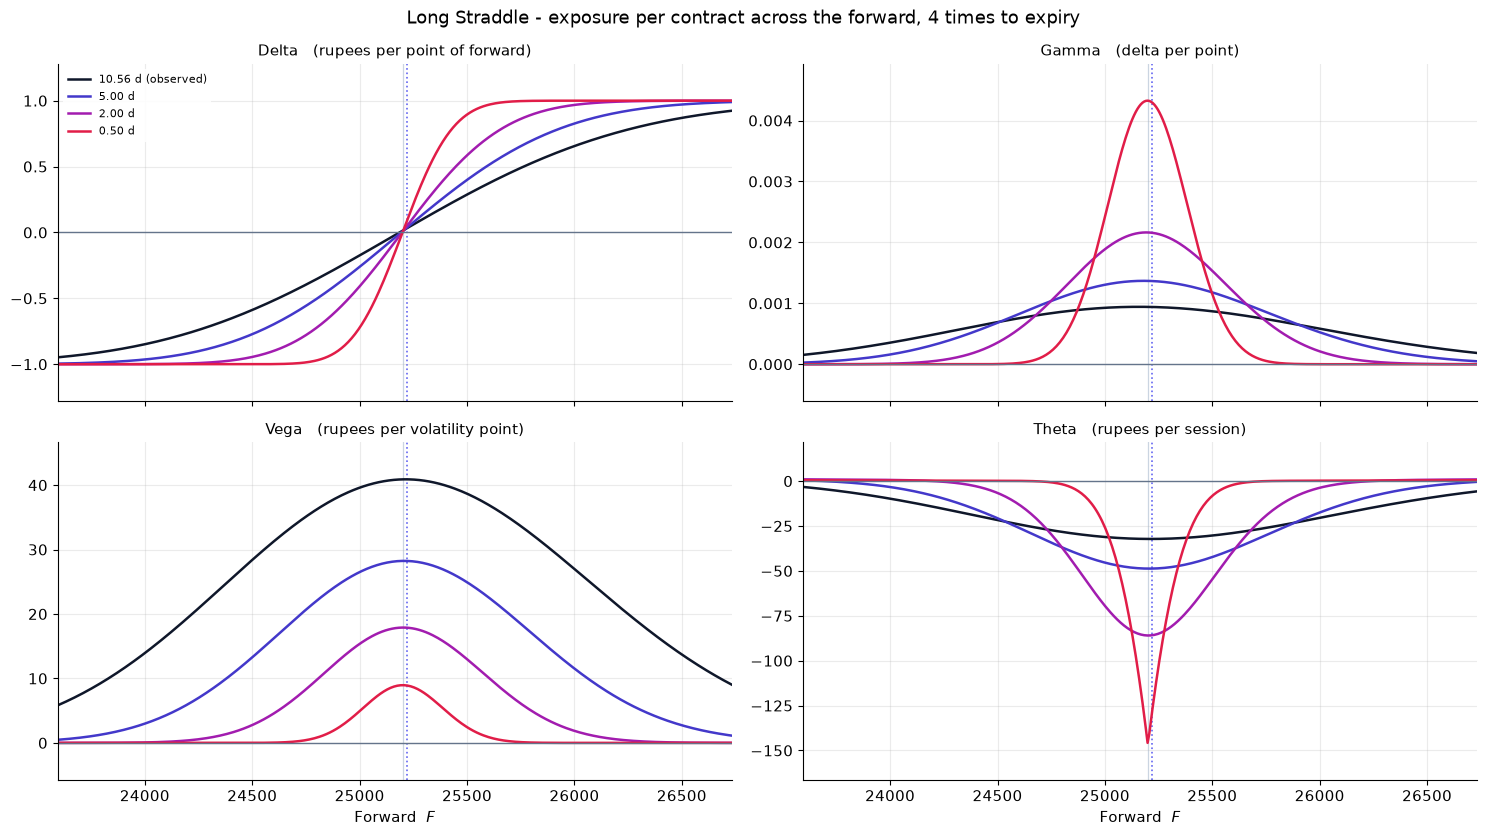

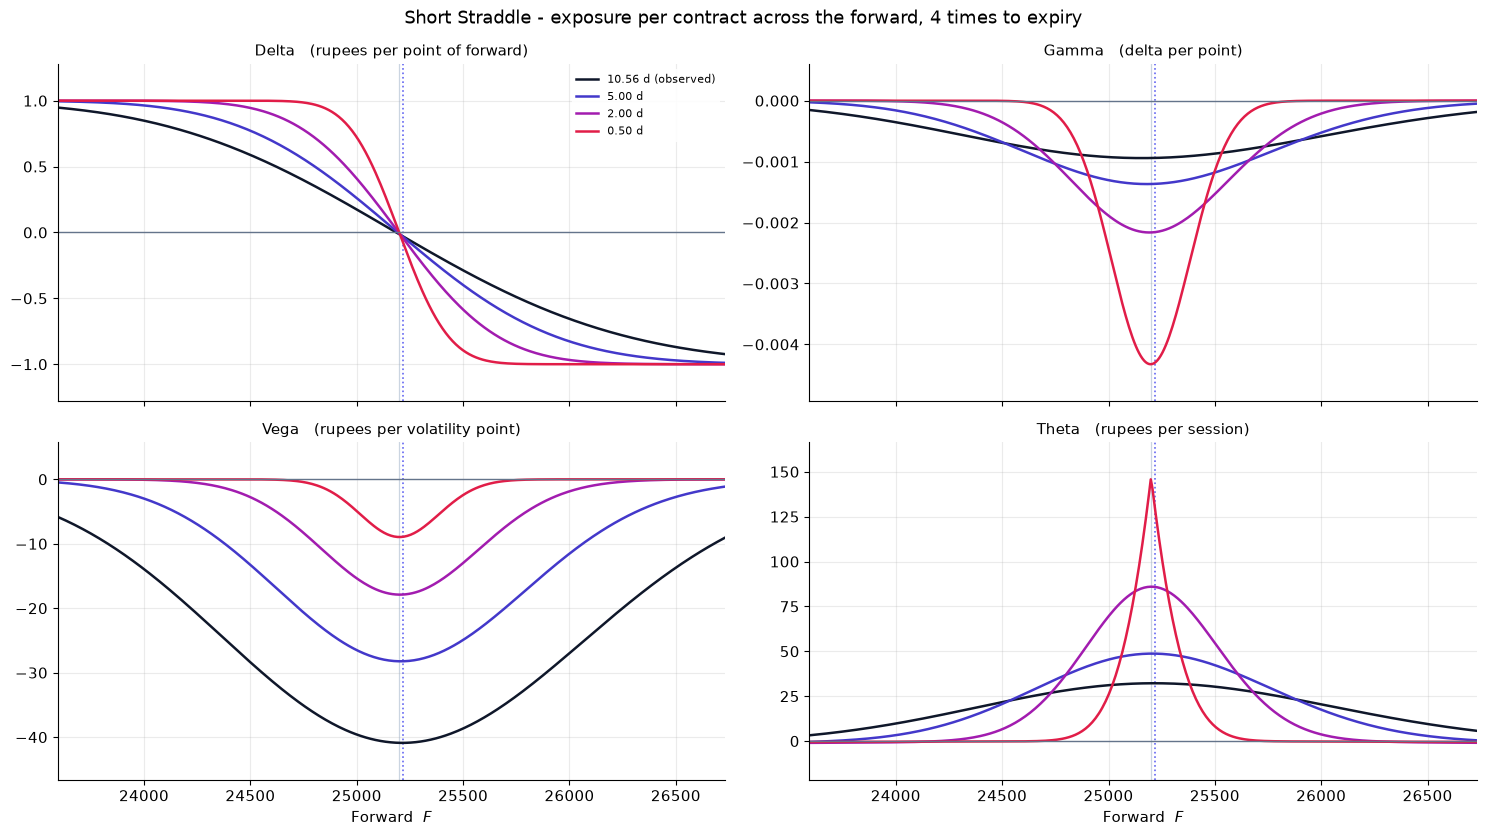

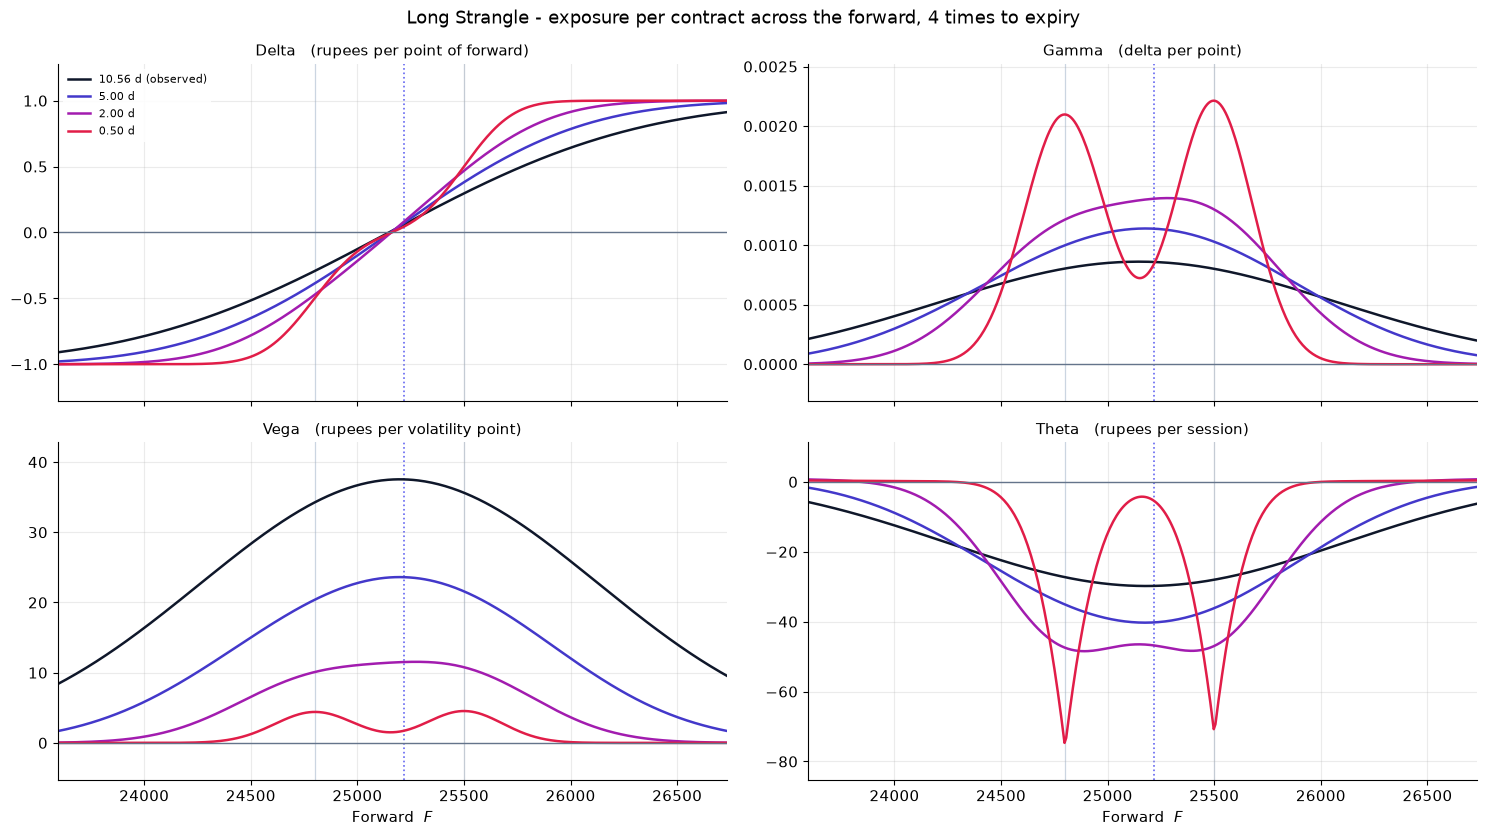

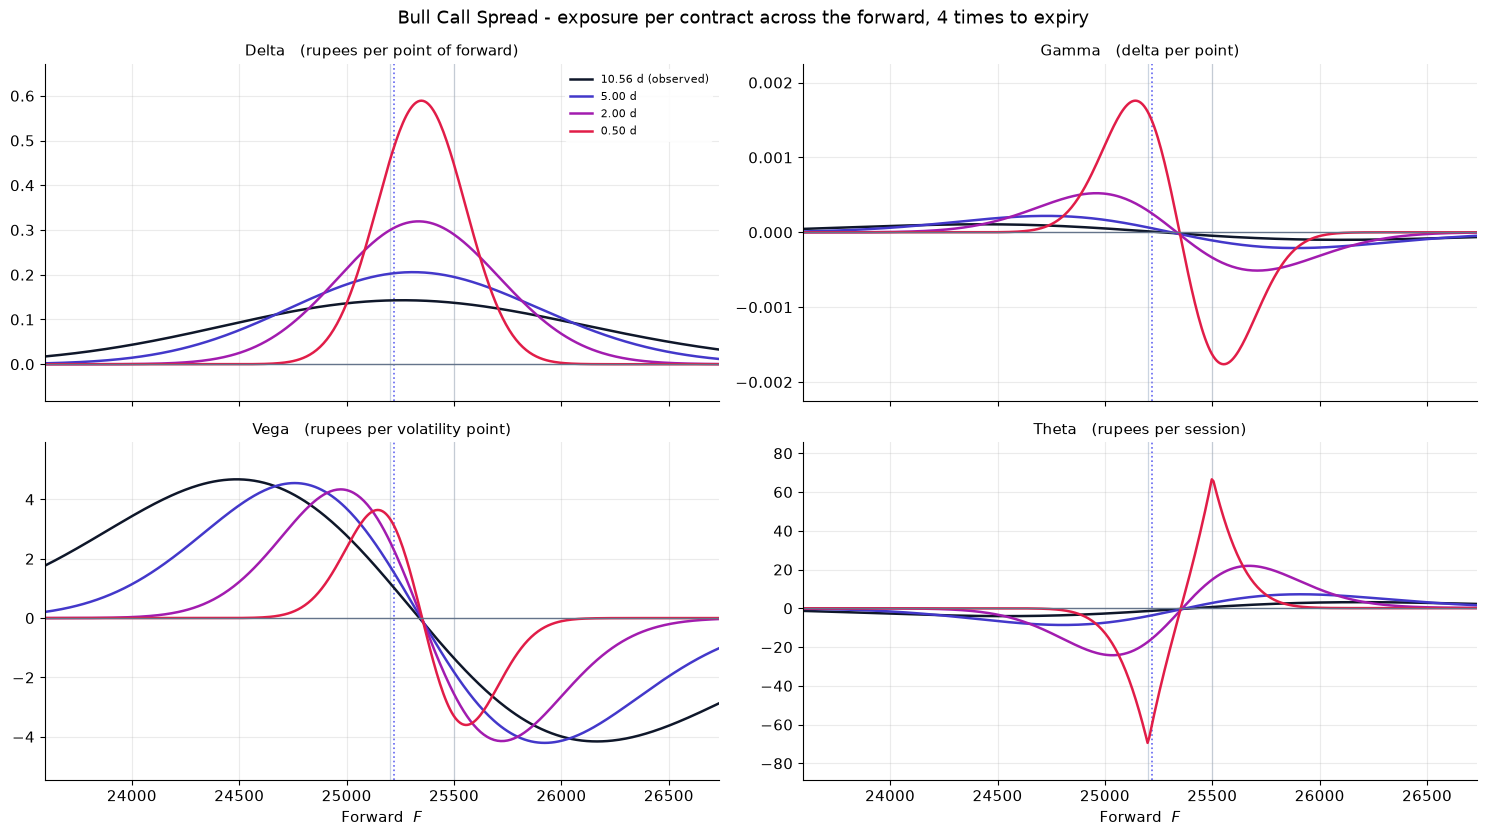

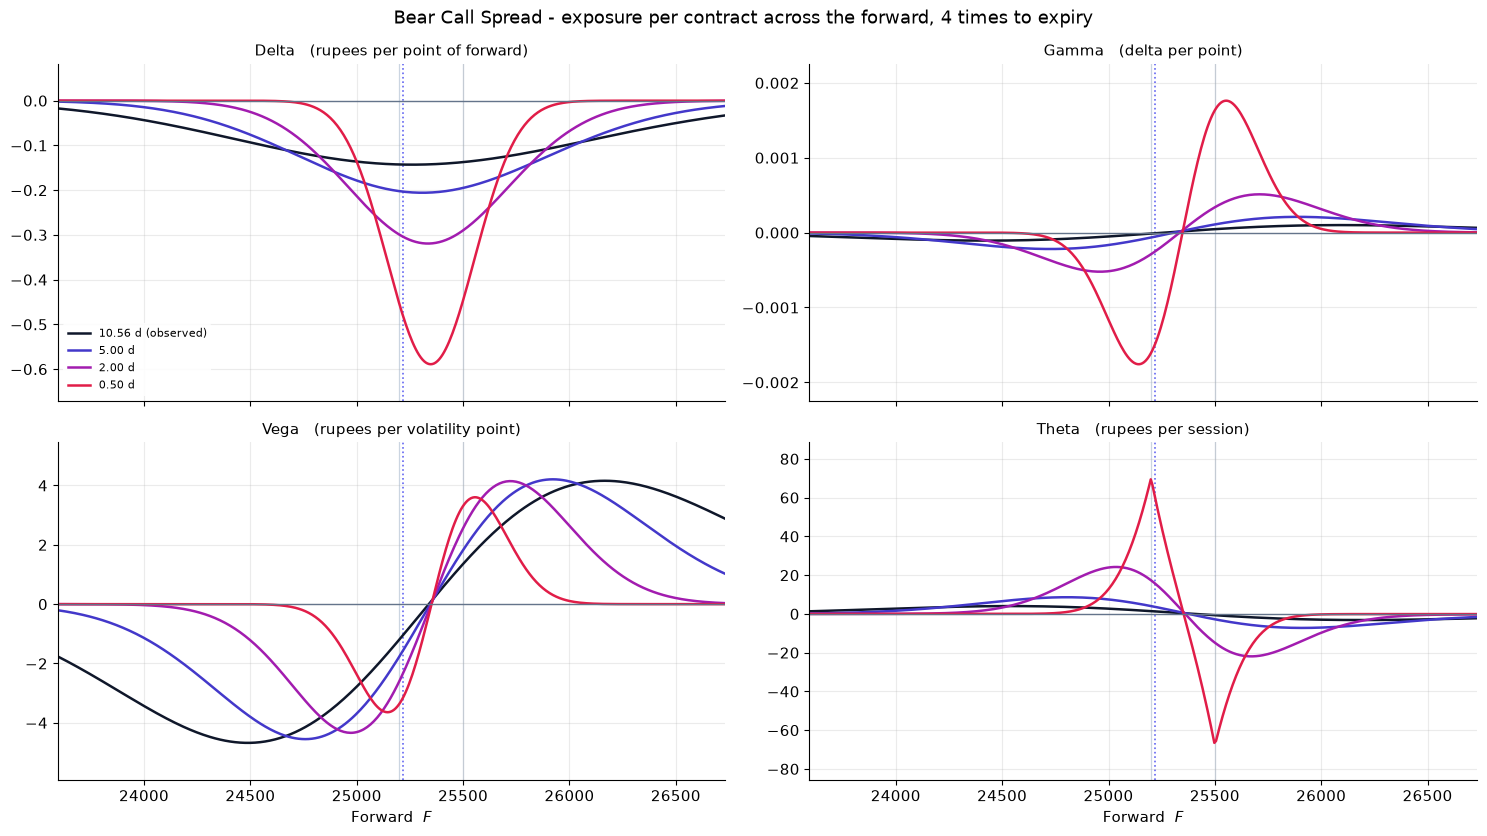

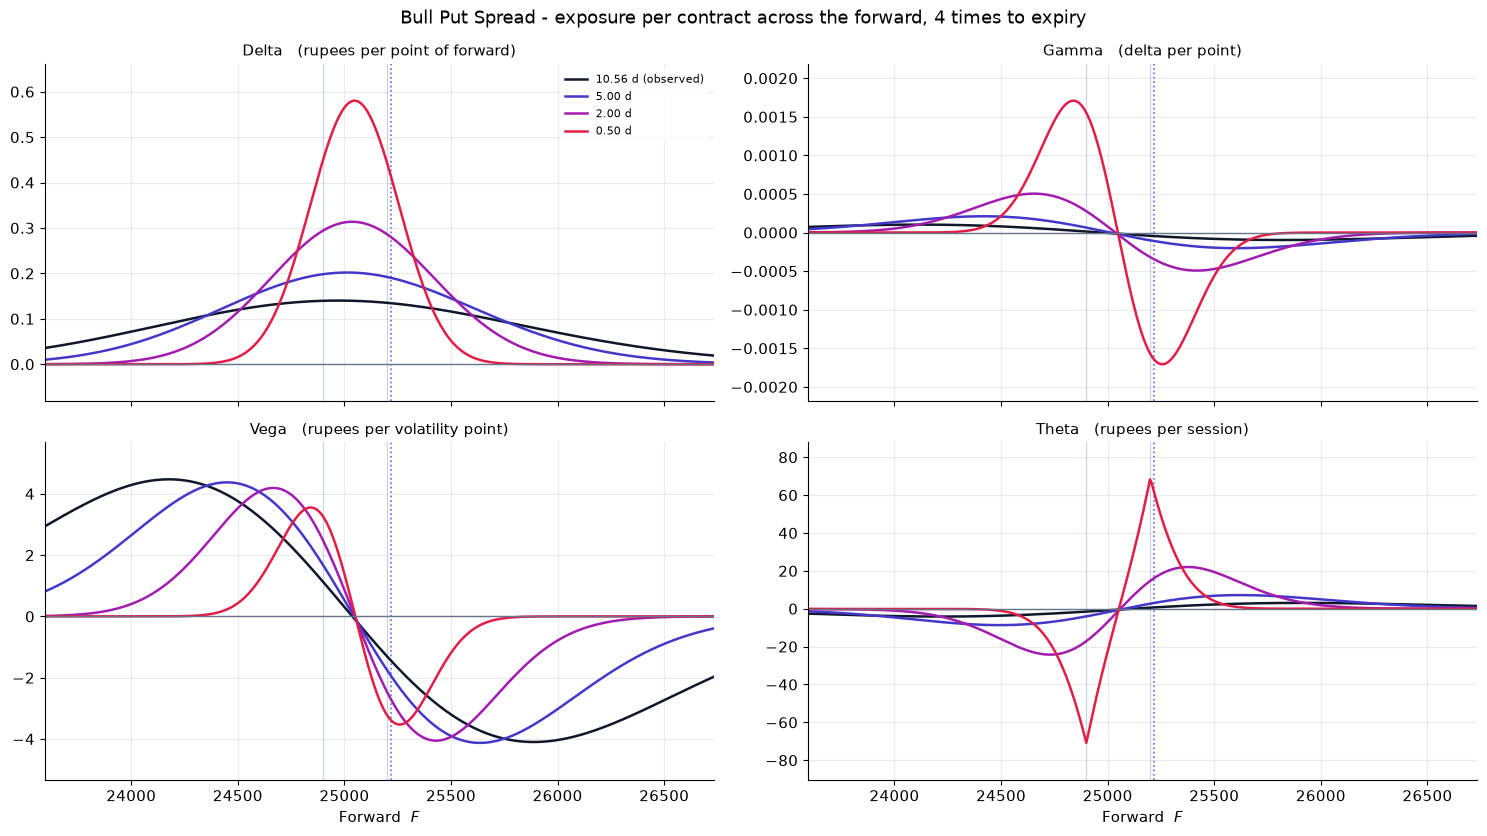

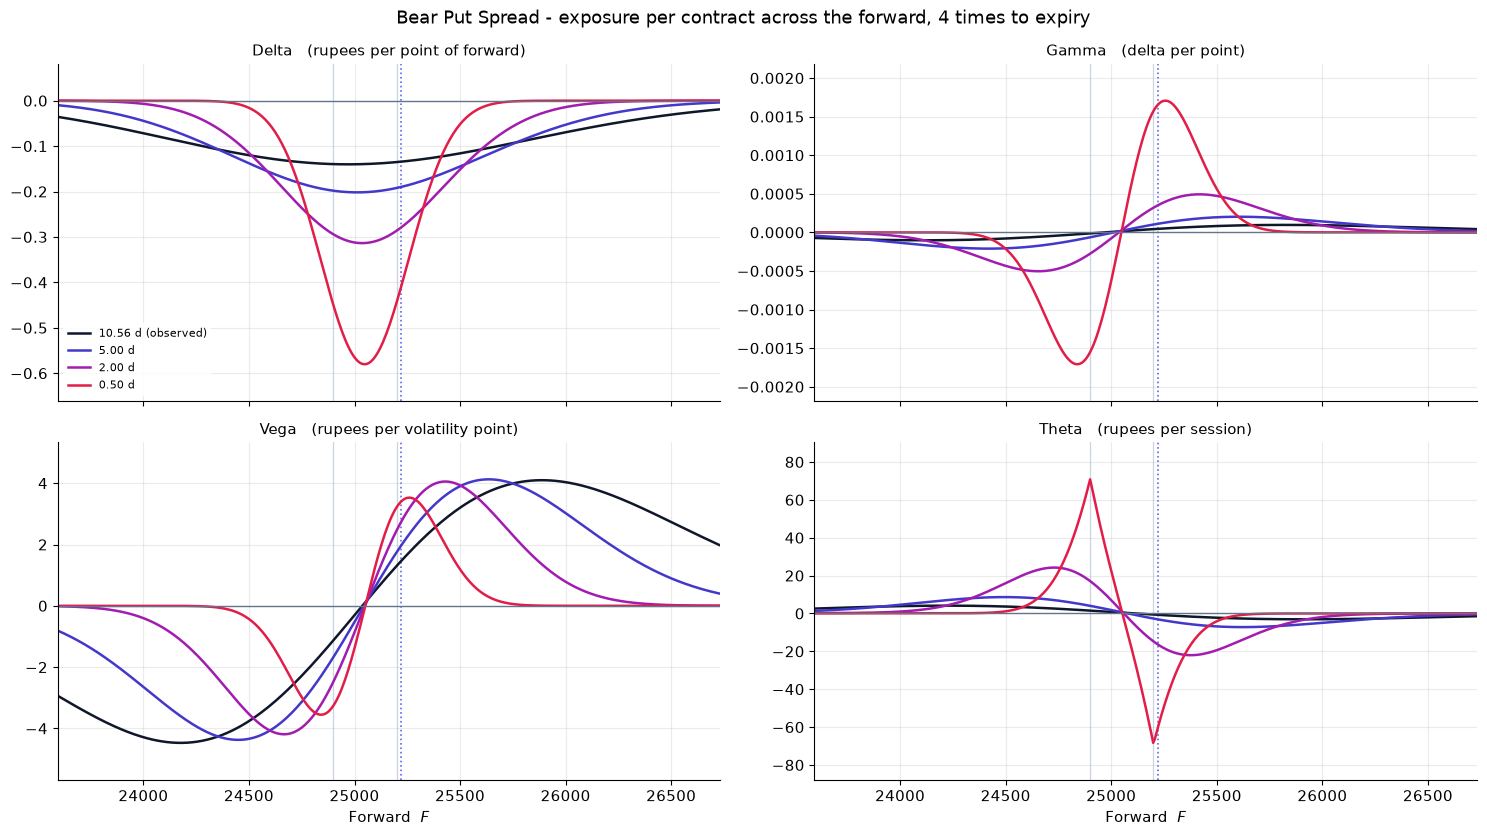

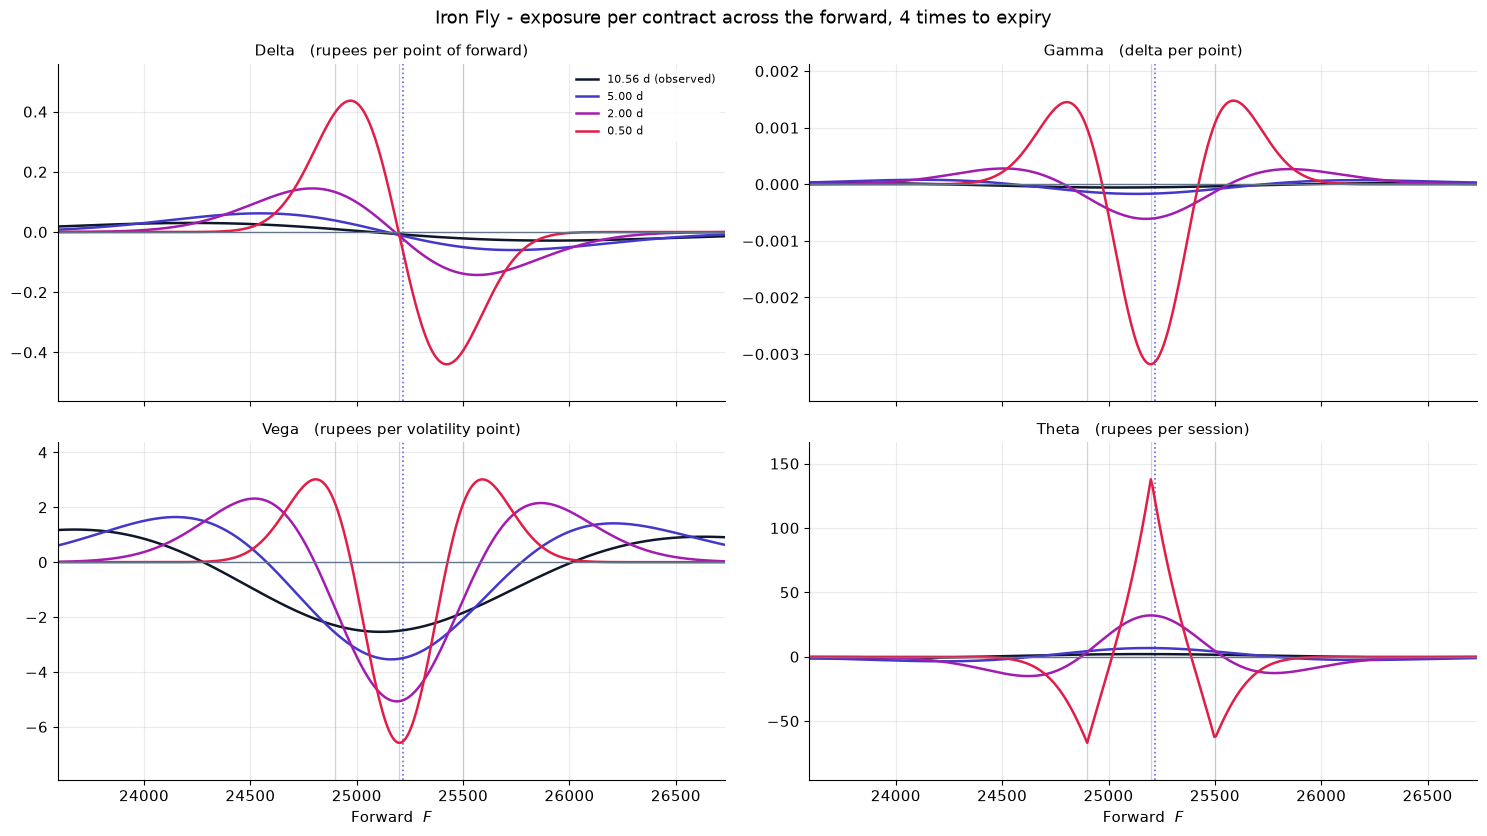

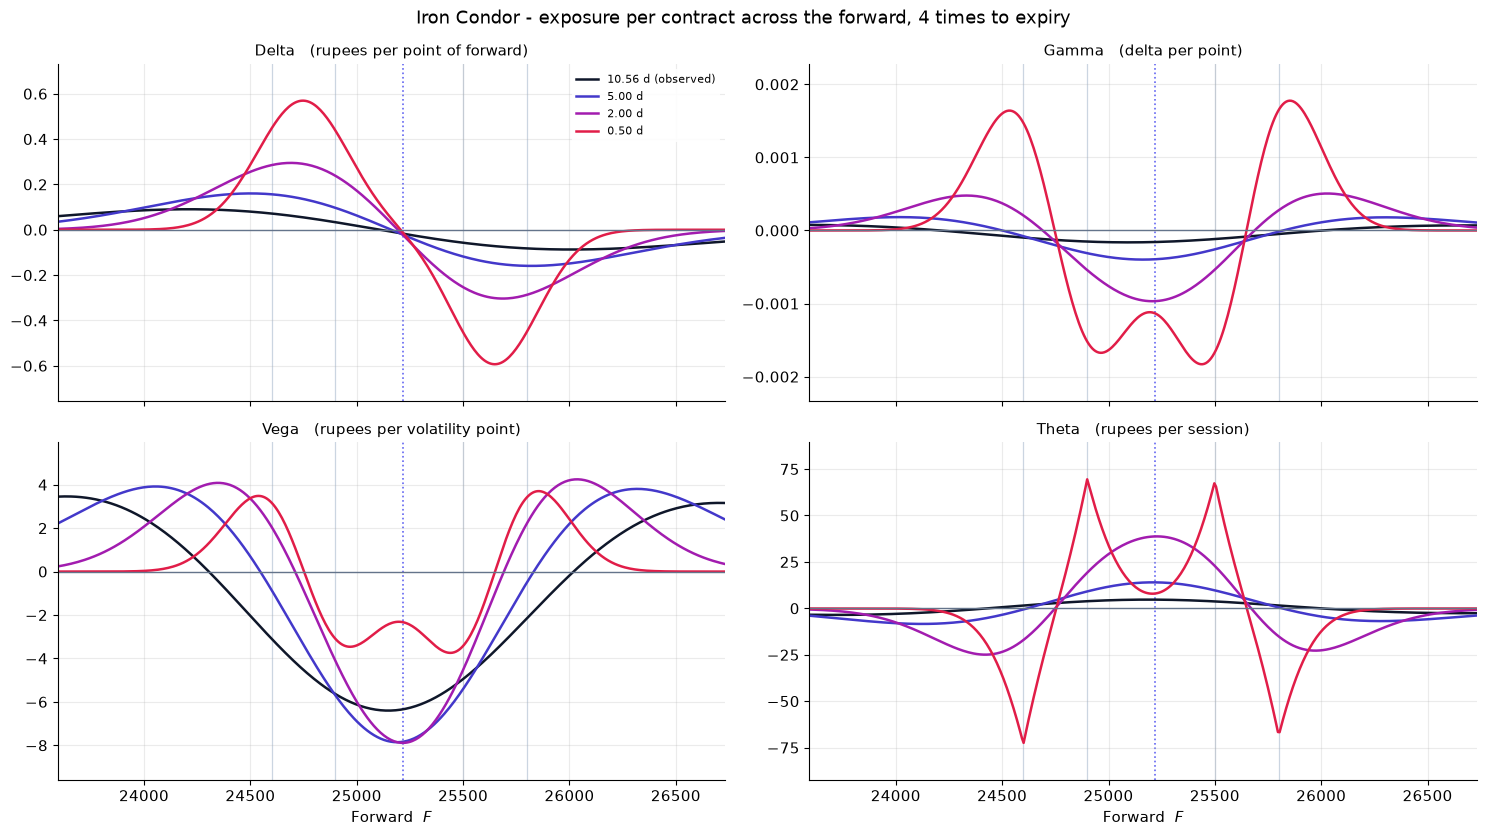

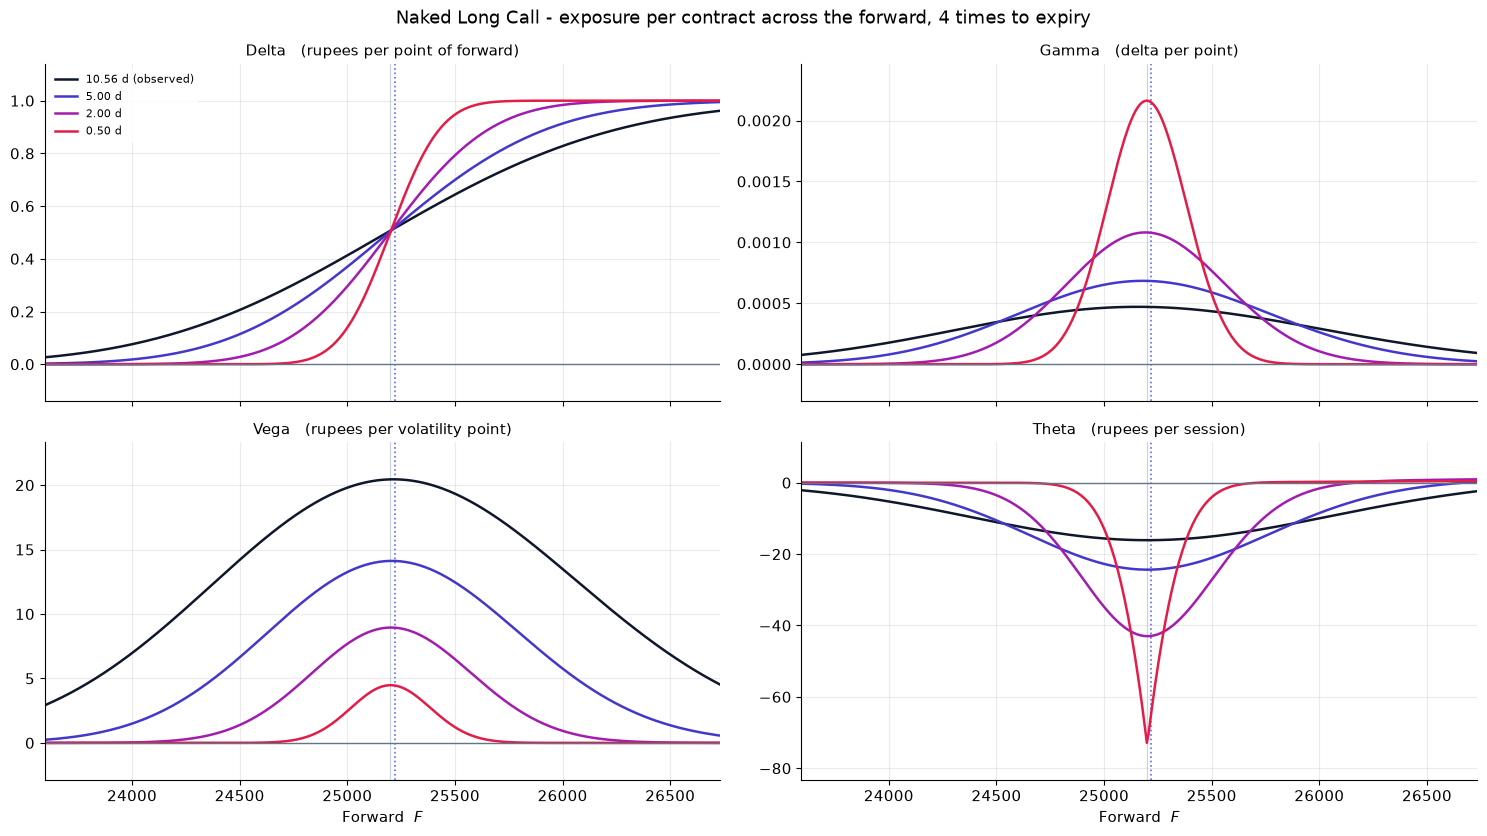

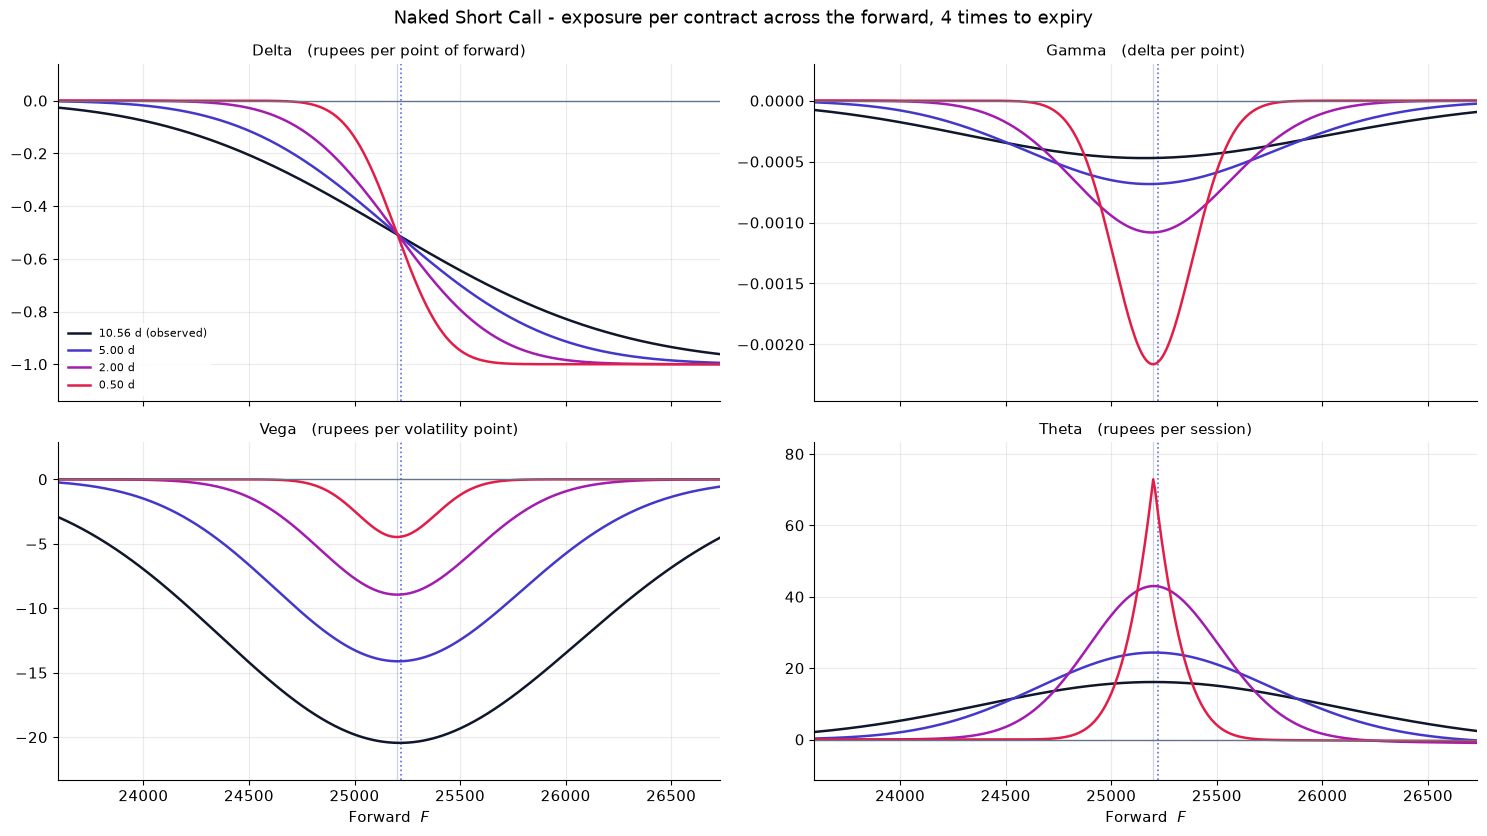

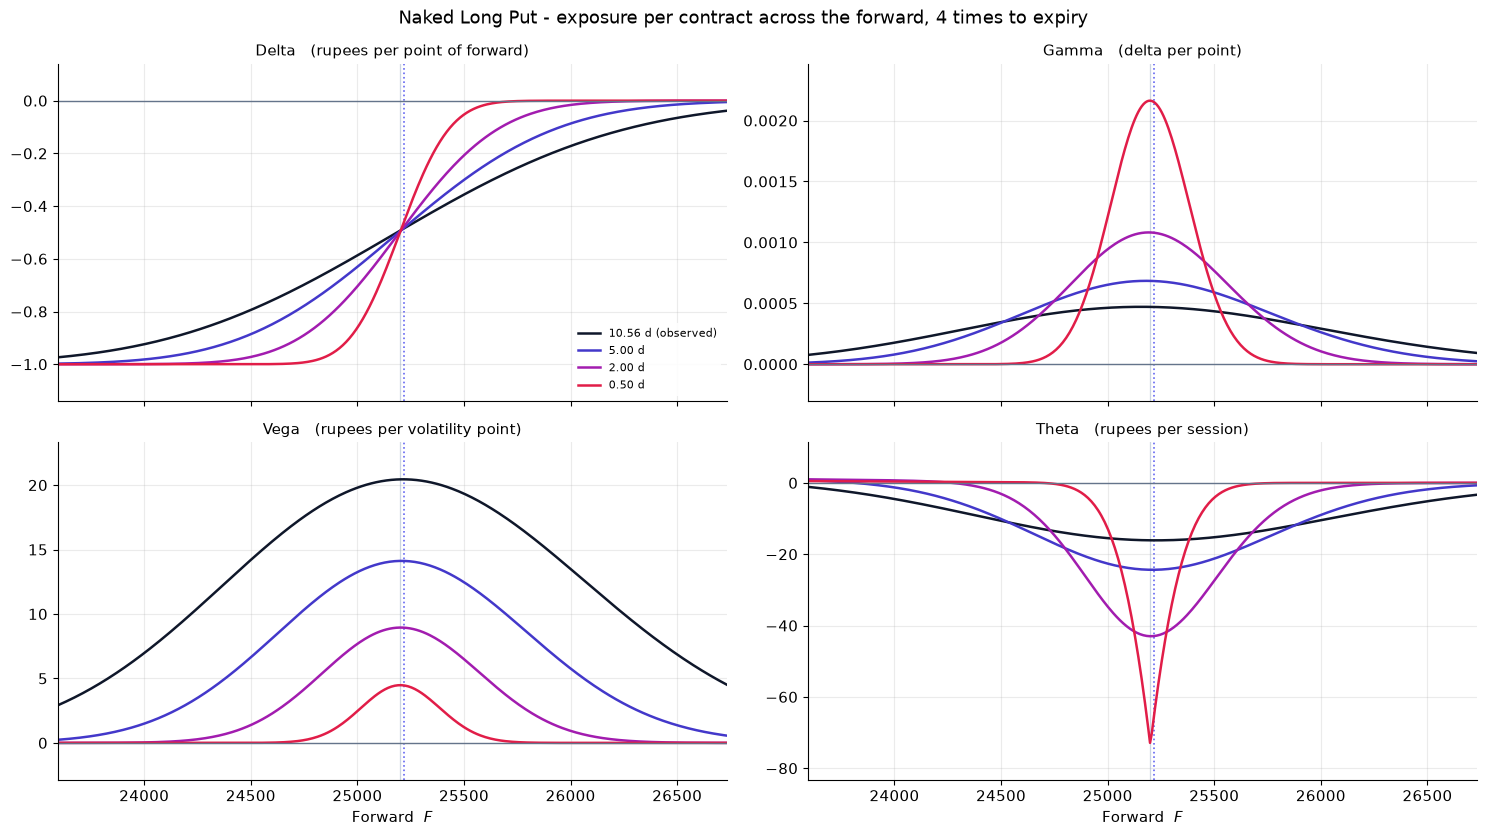

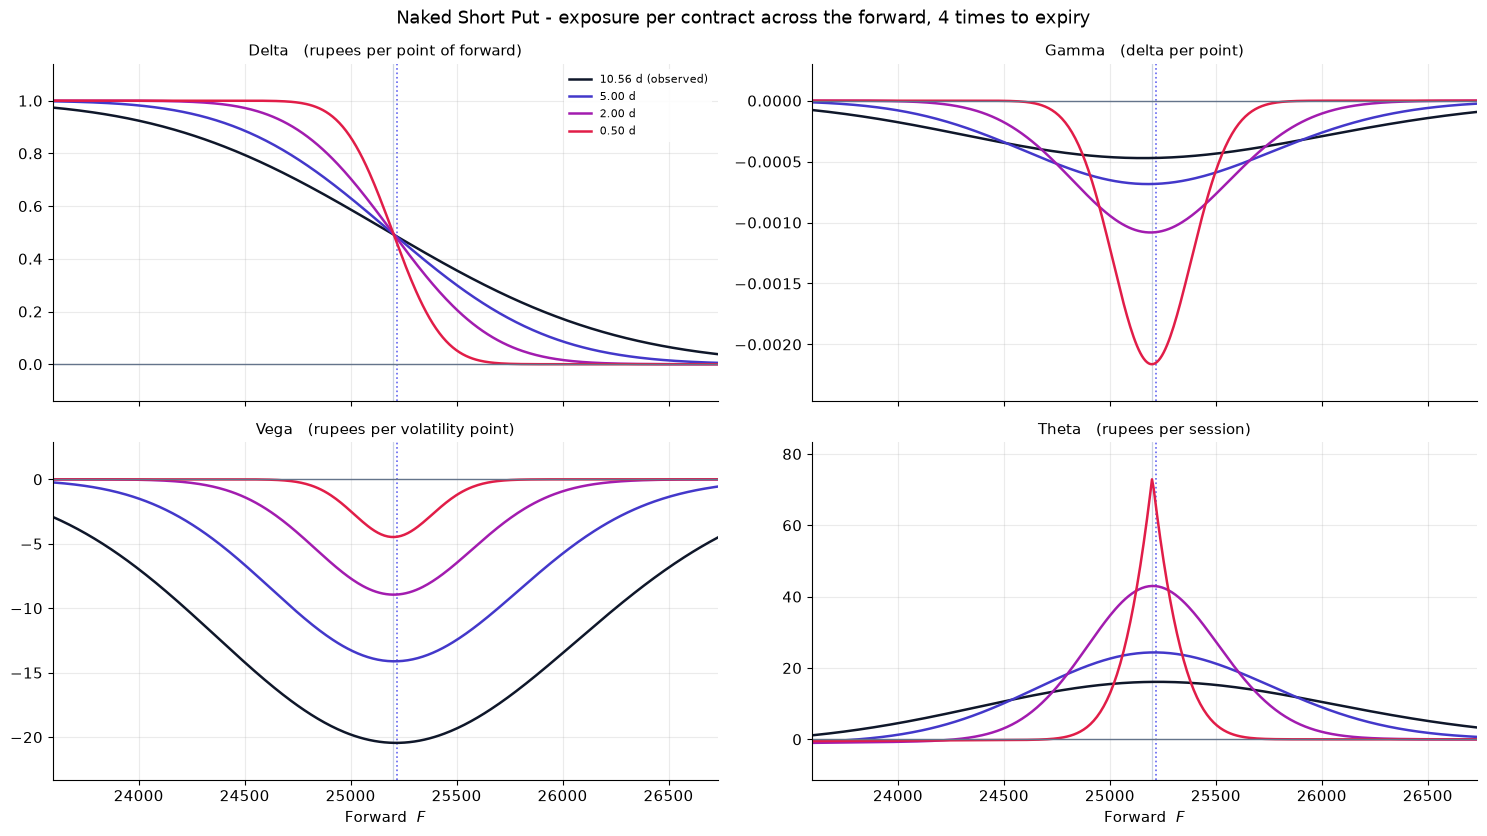

In [28]:
for name in STRATEGIES:
    plot_greek_profiles(name)

#### What the curves show

Three readings, each of which is easy to get wrong from the shapes alone.

**A position becomes a different risk as it ages.** The long straddle's $\Gamma$ more than
quadruples between the observed 10.56 days and half a day, while its $\nu$ falls to roughly a
fifth of where it started. It was bought as a volatility trade — an opinion about $\sigma$ — and
by the last session it is a pin trade, an opinion about *where the index closes*. Nothing about
the position changed. Only the clock did.

**$\Theta$ is not monotone for a structure with short strikes away from the money.** The iron
condor's $\Theta$ peaks near two days and then **collapses** into the final session. The reason is
visible on the payoff chart: a condor sitting between its short strikes has already converged on
its maximum profit, and a position with nothing left to gain has nothing left to decay. Anyone
carrying "theta always accelerates into expiry" as a rule will misread that panel, so it is worth
stating before the chart rather than after.

**$\Delta$ is bounded, and the bound is visible.** Each leg's $\Delta$ lies in $[-1, 1]$, so a
structure's cannot exceed $\sum q_i$ anywhere. The straddle's $\Delta$ flattens onto exactly
$\pm 1$ — one contract — as expiry approaches, because each leg's $\Delta$ is heading for 0 or 1 and
nothing in between survives.

The cell below prints the two structures at $\hat F$ and asserts the bound at every grid point of
every curve drawn above.

In [29]:
hdr = f"{'':<12}{'Long Straddle':>36}{'':>4}{'Iron Condor':>26}"
print(hdr)
print(f"{'dte_days':<12}{'gamma':>13}{'vega':>11}{'theta':>12}{'':>4}{'gamma':>13}{'theta':>13}")
print("-" * len(hdr))
for dte in DTE_CURVES:
    straddle = greeks_across(STRATEGIES["Long Straddle"], FORWARD, dte)
    condor = greeks_across(STRATEGIES["Iron Condor"], FORWARD, dte)
    print(f"{dte:<12,.2f}{float(straddle['gamma']):>13.7f}{float(straddle['vega']):>11,.3f}"
          f"{float(straddle['theta']):>12,.4f}{'':>4}{float(condor['gamma']):>13.7f}"
          f"{float(condor['theta']):>13,.4f}")

first, last = DTE_CURVES[0], DTE_CURVES[-1]
gamma_ratio = (float(greeks_across(STRATEGIES["Long Straddle"], FORWARD, last)["gamma"])
               / float(greeks_across(STRATEGIES["Long Straddle"], FORWARD, first)["gamma"]))
vega_ratio = (float(greeks_across(STRATEGIES["Long Straddle"], FORWARD, last)["vega"])
              / float(greeks_across(STRATEGIES["Long Straddle"], FORWARD, first)["vega"]))
print(f"\nstraddle from {first:.2f} d to {last:.2f} d:   "
      f"gamma x{gamma_ratio:.2f},   vega x{vega_ratio:.2f} ({vega_ratio:.0%} of the start)")

# The delta bound, at every point of every curve drawn above.
grid = np.linspace(WINDOW_LO, WINDOW_HI, 400)
for dte in DTE_CURVES:
    for name, legs in STRATEGIES.items():
        cap = sum(leg.quantity for leg in legs)
        peak = float(np.abs(greeks_across(legs, grid, dte)["delta"]).max())
        assert peak <= cap + 1e-9, f"{name} at {dte:.2f} d: delta {peak:,.4f} exceeds {cap:,.0f}"
print(f"|delta| <= sum(q) at all 400 grid points, {len(DTE_CURVES)} times to expiry, "
      f"{len(STRATEGIES)} structures")

                                   Long Straddle                   Iron Condor
dte_days            gamma       vega       theta            gamma        theta
------------------------------------------------------------------------------
10.56           0.0009397     40.891    -32.2121       -0.0001580       4.6882
5.00            0.0013654     28.228    -48.7144       -0.0003939      13.9887
2.00            0.0021573     17.873    -85.8503       -0.0009671      38.7264
0.50            0.0042973      8.909   -128.8674       -0.0011347       7.9783

straddle from 10.56 d to 0.50 d:   gamma x4.57,   vega x0.22 (22% of the start)
|delta| <= sum(q) at all 400 grid points, 4 times to expiry, 13 structures


## 10. Summary

One row per structure — thirteen positions, not twenty-six. `Dr` is a debit paid, `Cr` a credit
received. The caps belong to the position and are the same in either coordinate system; only the
breakeven columns differ, and they differ by $b$ throughout.

In [30]:
rows = []
for name, legs in STRATEGIES.items():
    ms = metrics_in(legs, SPOT_FRAMING, LOT_SIZE)
    mf = metrics_in(legs, FORWARD_FRAMING, LOT_SIZE)
    rows.append({
        "Strategy": name,
        "Legs": ", ".join(repr(leg) for leg in legs),
        "Max Profit": fmt(ms["max_profit"]),
        "Max Loss": fmt(ms["max_loss"]),
        "Breakeven(s) S_T": fmt_bes(ms["breakevens"]),
        "Breakeven(s) F": fmt_bes(mf["breakevens"]),
        "Net Premium": f"{abs(ms['net_premium']):,.0f} {'Dr' if ms['net_premium'] > 0 else 'Cr'}",
    })

summary = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 30)
summary

,Strategy,Legs,Max Profit,Max Loss,Breakeven(s) S_T,Breakeven(s) F,Net Premium
0,Long Straddle,"B 1x 25200 CE @ 344.05, B 1x 25200 PE @ 326.70",Unlimited,"-43,599","24,529.25, 25,870.75","24,648.12, 25,989.62","43,599 Dr"
1,Short Straddle,"S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70","43,599",Unlimited,"24,529.25, 25,870.75","24,648.12, 25,989.62","43,599 Cr"
2,Long Strangle,"B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10",Unlimited,"-25,109","24,413.70, 25,886.30","24,532.57, 26,005.17","25,109 Dr"
3,Bull Call Spread,"B 1x 25200 CE @ 344.05, S 1x 25500 CE @ 206.20","10,540","-8,960","25,337.85","25,456.72","8,960 Dr"
4,Bear Call Spread,"S 1x 25200 CE @ 344.05, B 1x 25500 CE @ 206.20","8,960","-10,540","25,337.85","25,456.72","8,960 Cr"
5,Bull Put Spread,"S 1x 25200 PE @ 326.70, B 1x 24900 PE @ 208.05","7,712","-11,788","25,081.35","25,200.22","7,712 Cr"
6,Bear Put Spread,"B 1x 25200 PE @ 326.70, S 1x 24900 PE @ 208.05","11,788","-7,712","25,081.35","25,200.22","7,712 Dr"
7,Iron Fly,"S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70, B 1x 255...","16,672","-2,828","24,943.50, 25,456.50","25,062.37, 25,575.37","16,672 Cr"
8,Iron Condor,"S 1x 25500 CE @ 206.20, S 1x 24900 PE @ 208.05, B 1x 258...","10,949","-8,551","24,731.55, 25,668.45","24,850.42, 25,787.32","10,949 Cr"
9,Naked Long Call,B 1x 25200 CE @ 344.05,Unlimited,"-22,363","25,544.05","25,662.92","22,363 Dr"


### What the framing changes

Almost nothing — and that is the claim being made, so it is asserted rather than asserted-looking.

$\Pi_F(F) = \Pi(F - b)$ is a translation, so **max profit, max loss and net premium are identical**
and **every breakeven moves by exactly $b = 118.87$**. The table below is that proof, structure by
structure; the notebook fails if any row disagrees.

The last check is the guard against the $\mathcal{K}_F$ trap: the naked long put's max profit must
read 1,616,764.50 in both coordinates. Re-deriving the candidate set in forward space with $0$
instead of $b$ returns 1,624,490.77 — plausible, 0.48% high, and silent.

In [31]:
rows = []
for name, legs in STRATEGIES.items():
    ms = metrics_in(legs, SPOT_FRAMING, LOT_SIZE)
    mf = metrics_in(legs, FORWARD_FRAMING, LOT_SIZE)

    # 1. the caps and the premium do not move
    assert ms["max_profit"] == mf["max_profit"], f"{name}: max profit moved"
    assert ms["max_loss"] == mf["max_loss"], f"{name}: max loss moved"
    assert ms["net_premium"] == mf["net_premium"], f"{name}: net premium moved"

    # 2. every breakeven moves by exactly the basis
    assert len(ms["breakevens"]) == len(mf["breakevens"]), f"{name}: breakeven count changed"
    shifts = [z - a for a, z in zip(ms["breakevens"], mf["breakevens"])]
    for s in shifts:
        assert abs(s - BASIS) < 0.01, f"{name}: breakeven shift {s:.4f} != basis {BASIS:.4f}"

    # 3. the whole curve is a translation, not just the six numbers
    grid = np.linspace(SPOT * 0.94, FORWARD * 1.06, 600)
    assert np.allclose(payoff_in(grid, legs, FORWARD_FRAMING, LOT_SIZE),
                       payoff_at_expiry(grid - BASIS, legs, LOT_SIZE)), f"{name}: not a translation"

    rows.append({
        "Strategy": name,
        "Max Profit": fmt(ms["max_profit"]),
        "Max Loss": fmt(ms["max_loss"]),
        "Caps move": "no",
        "Net moves": "no",
        "Breakevens": len(ms["breakevens"]),
        "Shift": ", ".join(f"{s:+.2f}" for s in shifts) or "-",
    })

# The regression guard for the forward-coordinate candidate set.
for framing in FRAMINGS:
    mp = metrics_in(STRATEGIES["Naked Long Put"], framing, LOT_SIZE)["max_profit"]
    assert abs(mp - 1_616_764.50) < 0.01, f"{framing.name}: naked long put max profit is {mp:,.2f}"

print(f"all {len(STRATEGIES)} structures: caps and net premium identical, "
      f"every breakeven shifted by exactly {BASIS:+.2f}")
print(f"naked long put max profit 1,616,764.50 in both coordinates "
      f"(the F = 0 trap would read 1,624,490.77)")
pd.DataFrame(rows)

all 13 structures: caps and net premium identical, every breakeven shifted by exactly +118.87
naked long put max profit 1,616,764.50 in both coordinates (the F = 0 trap would read 1,624,490.77)


,Strategy,Max Profit,Max Loss,Caps move,Net moves,Breakevens,Shift
0,Long Straddle,Unlimited,"-43,599",no,no,2,"+118.87, +118.87"
1,Short Straddle,"43,599",Unlimited,no,no,2,"+118.87, +118.87"
2,Long Strangle,Unlimited,"-25,109",no,no,2,"+118.87, +118.87"
3,Bull Call Spread,"10,540","-8,960",no,no,1,+118.87
4,Bear Call Spread,"8,960","-10,540",no,no,1,+118.87
5,Bull Put Spread,"7,712","-11,788",no,no,1,+118.87
6,Bear Put Spread,"11,788","-7,712",no,no,1,+118.87
7,Iron Fly,"16,672","-2,828",no,no,2,"+118.87, +118.87"
8,Iron Condor,"10,949","-8,551",no,no,2,"+118.87, +118.87"
9,Naked Long Call,Unlimited,"-22,363",no,no,1,+118.87
